# Implementasi Model Hybrid SARIMAX-LSTM dengan Multiple Exogenous Variables untuk Prediksi IHSG

**Pande Kadek Nathan Prabhaswara Sudiara Putra** — NIM: 235150207111051

Notebook ini mengimplementasikan model Hybrid SARIMAX-LSTM untuk memprediksi Indeks Harga Saham Gabungan (IHSG) dengan variabel eksogen:
- Kurs USD/IDR
- Harga Emas Dunia (XAU/USD)
- Indeks S&P 500

**Skenario Perbandingan:**
1. Model Hybrid SARIMAX-LSTM **Multivariat** (dengan 3 variabel eksogen)
2. Model Hybrid SARIMAX-LSTM **Univariat** (tanpa variabel eksogen)
3. Model **LSTM Tunggal**

**Metrik Evaluasi:** RMSE, MAE, MAPE

**Catatan Penting:** Semua model menggunakan pendekatan **rolling one-step-ahead prediction** pada data uji untuk memastikan perbandingan yang adil.

---
## 1. Instalasi dan Import Library

In [90]:
# Install required packages (uncomment if needed)
# !pip install yfinance pandas numpy matplotlib seaborn statsmodels scikit-learn tensorflow

In [91]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
from tqdm import tqdm

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

TensorFlow version: 2.21.0
NumPy version: 2.4.6
Pandas version: 3.0.3


---
## 2. Pengumpulan Data

Data diambil dari Yahoo Finance menggunakan library `yfinance` untuk periode **1 Januari 2019 – 31 Desember 2024**.

| No | Variabel | Ticker Yahoo Finance | Keterangan |
|---|---|---|---|
| 1 | IHSG (Closing Price) | `^JKSE` | Variabel dependen |
| 2 | Kurs USD/IDR | `IDR=X` | Variabel eksogen |
| 3 | Harga Emas (XAU/USD) | `GC=F` | Variabel eksogen |
| 4 | Indeks S&P 500 | `^GSPC` | Variabel eksogen |

In [92]:
# Define date range
START_DATE = '2010-01-01'
END_DATE = '2026-05-01'

# Define tickers
tickers = {
    'IHSG': '^JKSE',
    'USD_IDR': 'IDR=X',
    'Gold': 'GC=F',
    'SP500': '^GSPC'
}

# Download data
raw_data = {}
for name, ticker in tickers.items():
    print(f"Downloading {name} ({ticker})...")
    data = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False, multi_level_index=False)
    raw_data[name] = data['Close'].squeeze()
    print(f"  -> {len(data)} records downloaded")

# Combine into a single DataFrame
df = pd.DataFrame(raw_data)
print(f"\nCombined shape (before cleaning): {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
df.head(10)

  -> 3961 records downloaded
  -> 4249 records downloaded
  -> 4105 records downloaded
  -> 4106 records downloaded

Combined shape (before cleaning): (4256, 4)
Date range: 2010-01-01 00:00:00 to 2026-04-30 00:00:00


,IHSG,USD_IDR,Gold,SP500
Date,,,,
2010-01-01,NaN,9385.599609,NaN,NaN
2010-01-04,2575.312988,9364.200195,1117.699951,1132.989990
2010-01-05,2605.175537,9305.200195,1118.099976,1136.520020
2010-01-06,2603.195557,9218.099609,1135.900024,1137.140015
2010-01-07,2586.794189,9272.500000,1133.099976,1141.689941
2010-01-08,2614.268311,9212.700195,1138.199951,1144.979980
2010-01-11,2632.101562,9148.099609,1150.699951,1146.979980
2010-01-12,2659.447266,9171.000000,1128.900024,1136.219971
2010-01-13,2632.769531,9141.000000,1136.400024,1145.680054


---
## 3. Pra-pemrosesan Data (Preprocessing)

### 3.1 Penanganan Missing Values

Karena hari libur bursa berbeda antar negara, terdapat missing values. Digunakan metode **forward fill** kemudian **backward fill** untuk memastikan tidak ada NaN.

In [93]:
# Check missing values before cleaning
print("Missing values sebelum cleaning:")
print(df.isnull().sum())
print(f"\nTotal rows with any NaN: {df.isnull().any(axis=1).sum()}")

Missing values sebelum cleaning:
IHSG       295
USD_IDR      7
Gold       151
SP500      150
dtype: int64

Total rows with any NaN: 412


In [94]:
# Handle missing values using forward fill then backward fill
df = df.ffill().bfill()

# Drop any remaining rows with NaN (if any)
df = df.dropna()

df = df.asfreq('B')

df = df.ffill()

print("Missing values setelah cleaning:")
print(df.isnull().sum())
print(f"\nFinal dataset shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Missing values setelah cleaning:
IHSG       0
USD_IDR    0
Gold       0
SP500      0
dtype: int64

Final dataset shape: (4260, 4)
Date range: 2010-01-01 00:00:00 to 2026-04-30 00:00:00


### 3.2 Exploratory Data Analysis (EDA)

In [95]:
# Descriptive statistics
df.describe().round(2)

,IHSG,USD_IDR,Gold,SP500
count,4260.00,4260.00,4260.00,4260.00
mean,5576.62,13132.52,1727.24,3025.34
std,1334.39,2468.03,730.42,1576.07
min,2475.48,888.11,1050.80,1022.58
25%,4559.70,11543.75,1271.78,1837.18
50%,5705.23,13775.00,1528.65,2640.87
75%,6651.38,14845.18,1849.52,4140.24
max,9134.70,17334.20,5318.40,7209.01


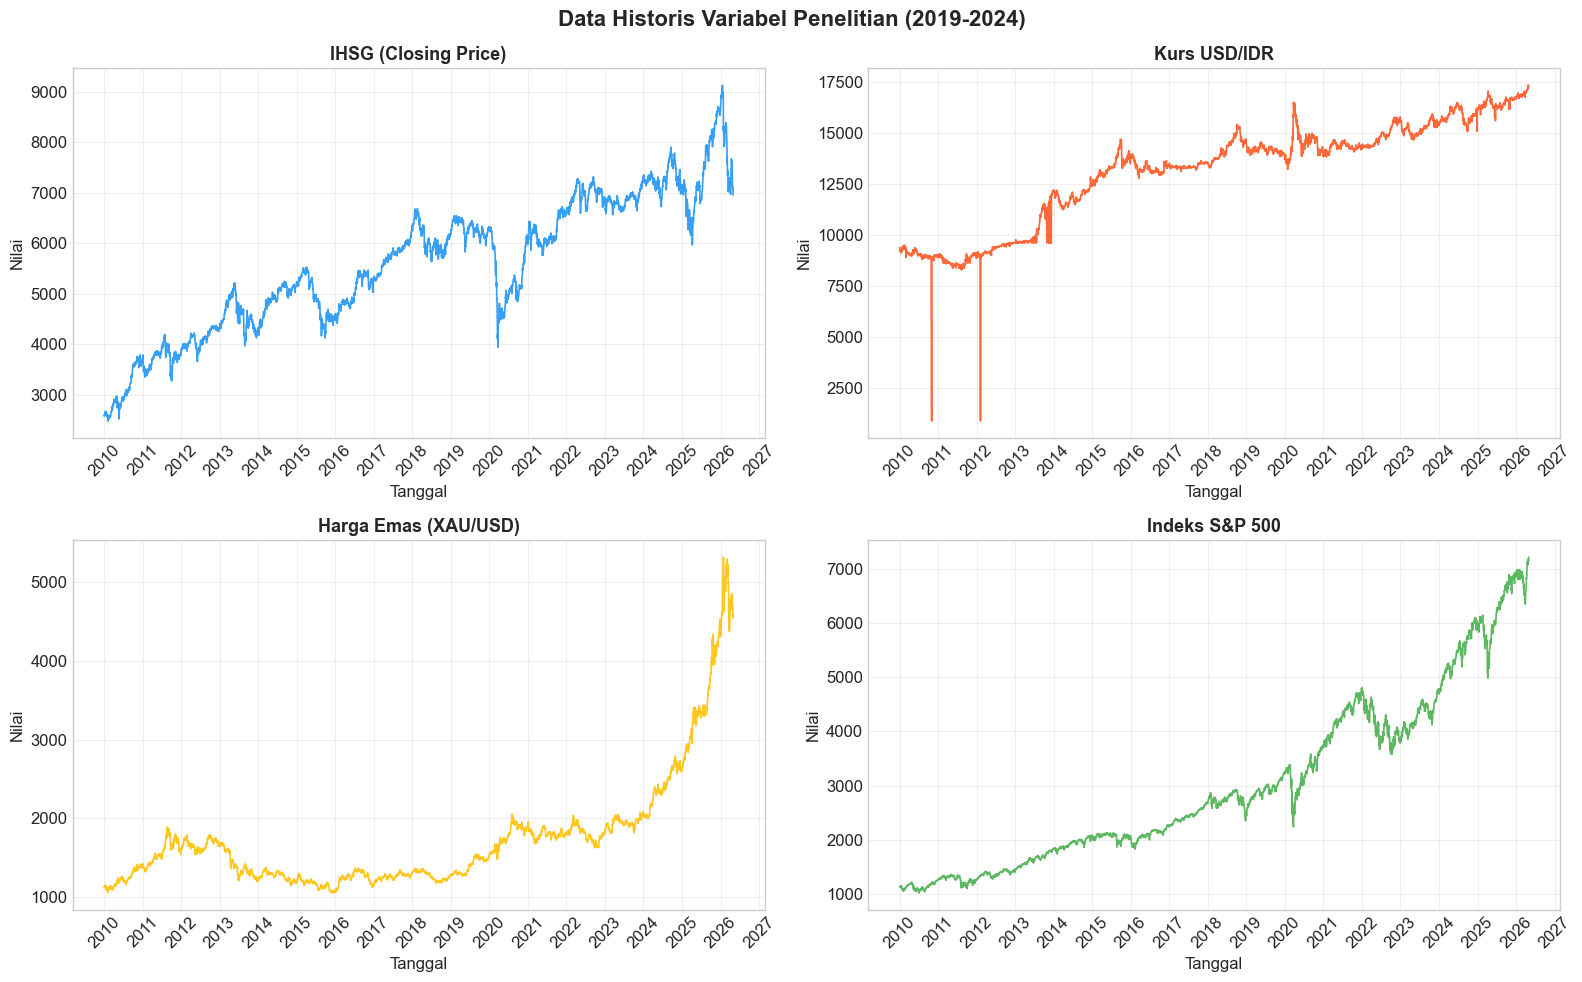

In [96]:
# Plot all variables
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Data Historis Variabel Penelitian (2019-2024)', fontsize=16, fontweight='bold')

variables = ['IHSG', 'USD_IDR', 'Gold', 'SP500']
titles = ['IHSG (Closing Price)', 'Kurs USD/IDR', 'Harga Emas (XAU/USD)', 'Indeks S&P 500']
colors = ['#2196F3', '#FF5722', '#FFC107', '#4CAF50']

for ax, var, title, color in zip(axes.flat, variables, titles, colors):
    ax.plot(df.index, df[var], color=color, linewidth=1.2, alpha=0.9)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Tanggal')
    ax.set_ylabel('Nilai')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_time_series.png', dpi=150, bbox_inches='tight')
plt.show()

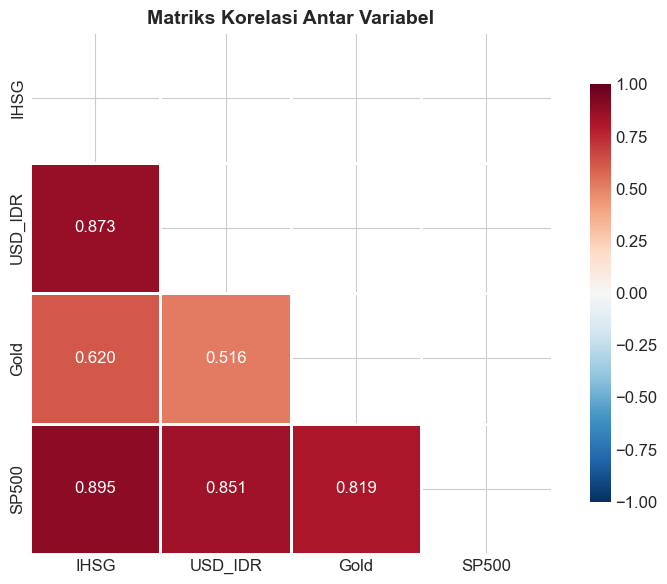

Korelasi variabel eksogen terhadap IHSG:
SP500      0.895229
USD_IDR    0.873305
Gold       0.619724
Name: IHSG, dtype: float64


In [97]:
# Correlation matrix
fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=1,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Matriks Korelasi Antar Variabel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Korelasi variabel eksogen terhadap IHSG:")
print(corr_matrix['IHSG'].drop('IHSG').sort_values(ascending=False))

### 3.3 Uji Stasioneritas (Augmented Dickey-Fuller Test)

In [98]:
def adf_test(series, name):
    """Perform Augmented Dickey-Fuller test and return results."""
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"\n{'='*50}")
    print(f"ADF Test: {name}")
    print(f"{'='*50}")
    print(f"  ADF Statistic  : {result[0]:.6f}")
    print(f"  p-value        : {result[1]:.6f}")
    print(f"  Lags Used      : {result[2]}")
    print(f"  Observations   : {result[3]}")
    for key, value in result[4].items():
        print(f"  Critical Value ({key}): {value:.6f}")
    
    is_stationary = result[1] < 0.05
    print(f"  Conclusion     : {'STASIONER ✓' if is_stationary else 'TIDAK STASIONER ✗ (perlu differencing)'}")
    return is_stationary, result[1]

# Test stationarity for all variables (level)
print("=" * 60)
print("UJI STASIONERITAS - DATA LEVEL (ORIGINAL)")
print("=" * 60)

stationarity_results = {}
for col in df.columns:
    is_stat, pval = adf_test(df[col], col)
    stationarity_results[col] = {'level': is_stat, 'p_value_level': pval}

UJI STASIONERITAS - DATA LEVEL (ORIGINAL)

ADF Test: IHSG
  ADF Statistic  : -2.037525
  p-value        : 0.270366
  Lags Used      : 11
  Observations   : 4248
  Critical Value (1%): -3.431890
  Critical Value (5%): -2.862221
  Critical Value (10%): -2.567132
  Conclusion     : TIDAK STASIONER ✗ (perlu differencing)

ADF Test: USD_IDR
  ADF Statistic  : -0.803383
  p-value        : 0.818126
  Lags Used      : 14
  Observations   : 4245
  Critical Value (1%): -3.431891
  Critical Value (5%): -2.862221
  Critical Value (10%): -2.567133
  Conclusion     : TIDAK STASIONER ✗ (perlu differencing)

ADF Test: Gold
  ADF Statistic  : 2.874772
  p-value        : 1.000000
  Lags Used      : 29
  Observations   : 4230
  Critical Value (1%): -3.431897
  Critical Value (5%): -2.862224
  Critical Value (10%): -2.567134
  Conclusion     : TIDAK STASIONER ✗ (perlu differencing)

ADF Test: SP500
  ADF Statistic  : 1.647593
  p-value        : 0.997994
  Lags Used      : 28
  Observations   : 4231
  Crit

In [99]:
# Test stationarity on first difference
print("\n" + "=" * 60)
print("UJI STASIONERITAS - FIRST DIFFERENCE (d=1)")
print("=" * 60)

df_diff = df.diff().dropna()

for col in df.columns:
    is_stat, pval = adf_test(df_diff[col], f"{col} (diff)")
    stationarity_results[col]['first_diff'] = is_stat
    stationarity_results[col]['p_value_diff'] = pval

# Summary table
stat_df = pd.DataFrame(stationarity_results).T
print("\n\nRingkasan Uji Stasioneritas:")
stat_df


UJI STASIONERITAS - FIRST DIFFERENCE (d=1)

ADF Test: IHSG (diff)
  ADF Statistic  : -20.567114
  p-value        : 0.000000
  Lags Used      : 10
  Observations   : 4248
  Critical Value (1%): -3.431890
  Critical Value (5%): -2.862221
  Critical Value (10%): -2.567132
  Conclusion     : STASIONER ✓

ADF Test: USD_IDR (diff)
  ADF Statistic  : -21.413553
  p-value        : 0.000000
  Lags Used      : 13
  Observations   : 4245
  Critical Value (1%): -3.431891
  Critical Value (5%): -2.862221
  Critical Value (10%): -2.567133
  Conclusion     : STASIONER ✓

ADF Test: Gold (diff)
  ADF Statistic  : -10.712672
  p-value        : 0.000000
  Lags Used      : 28
  Observations   : 4230
  Critical Value (1%): -3.431897
  Critical Value (5%): -2.862224
  Critical Value (10%): -2.567134
  Conclusion     : STASIONER ✓

ADF Test: SP500 (diff)
  ADF Statistic  : -12.843401
  p-value        : 0.000000
  Lags Used      : 27
  Observations   : 4231
  Critical Value (1%): -3.431897
  Critical Value (

,level,p_value_level,first_diff,p_value_diff
IHSG,False,0.270366,True,0.0
USD_IDR,False,0.818126,True,0.0
Gold,False,1.0,True,0.0
SP500,False,0.997994,True,0.0


### 3.4 ACF dan PACF Plot (IHSG)

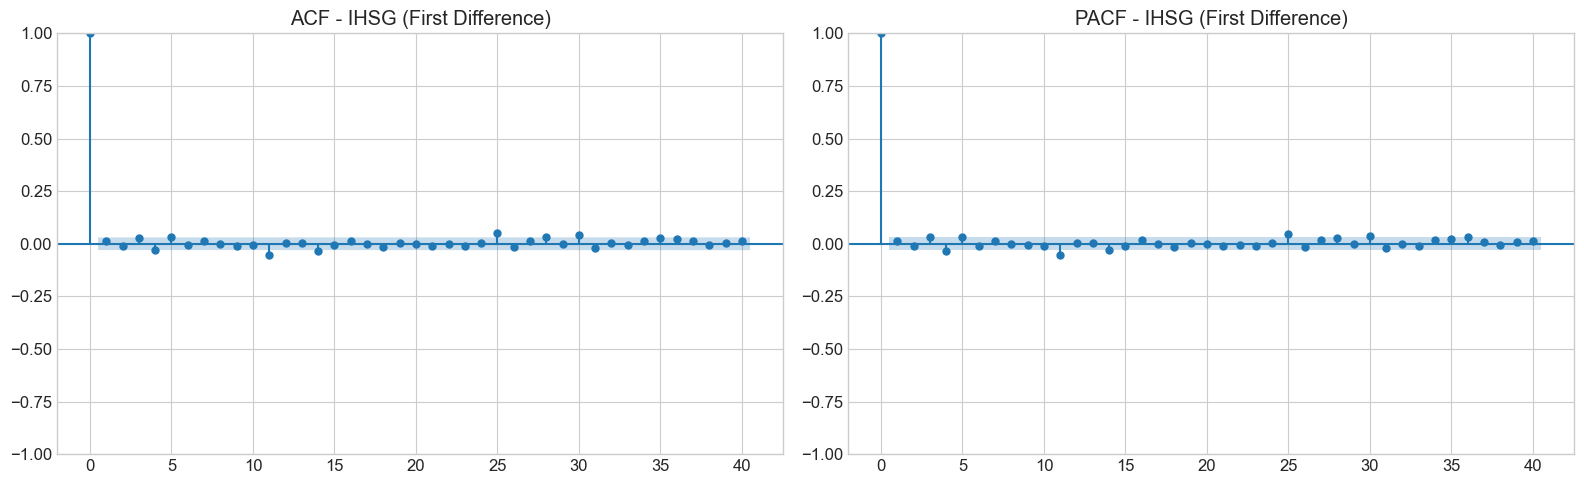

In [100]:
# ACF and PACF plots for IHSG (differenced)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(df_diff['IHSG'], lags=40, ax=axes[0], title='ACF - IHSG (First Difference)')
plot_pacf(df_diff['IHSG'], lags=40, ax=axes[1], title='PACF - IHSG (First Difference)', method='ywm')

plt.tight_layout()
plt.savefig('acf_pacf_ihsg.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Pembagian Data (Train/Test Split)

Data dibagi menjadi **80% data latih** dan **20% data uji**.

In [101]:
# Train/Test Split (80/20)
train_size = int(len(df) * 0.9)

train_data = df.iloc[:train_size]
test_data = df.iloc[train_size:]

print(f"Total data     : {len(df)}")
print(f"Training data  : {len(train_data)} ({len(train_data)/len(df)*100:.1f}%)")
print(f"Testing data   : {len(test_data)} ({len(test_data)/len(df)*100:.1f}%)")
print(f"\nTraining period: {train_data.index[0].date()} to {train_data.index[-1].date()}")
print(f"Testing period : {test_data.index[0].date()} to {test_data.index[-1].date()}")

Total data     : 4260
Training data  : 3834 (90.0%)
Testing data   : 426 (10.0%)

Training period: 2010-01-01 to 2024-09-11
Testing period : 2024-09-12 to 2026-04-30


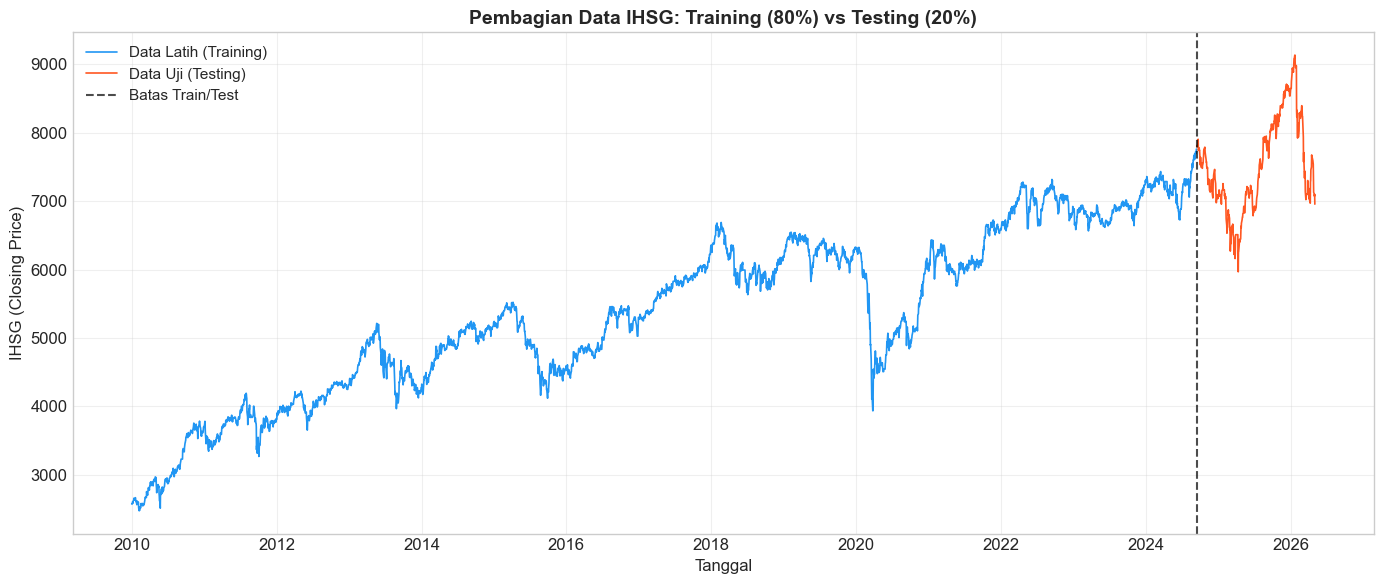

In [102]:
# Visualize train/test split
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train_data.index, train_data['IHSG'], color='#2196F3', label='Data Latih (Training)', linewidth=1.2)
ax.plot(test_data.index, test_data['IHSG'], color='#FF5722', label='Data Uji (Testing)', linewidth=1.2)
ax.axvline(x=train_data.index[-1], color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Batas Train/Test')
ax.set_title('Pembagian Data IHSG: Training (80%) vs Testing (20%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tanggal')
ax.set_ylabel('IHSG (Closing Price)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Fungsi Evaluasi Model

Metrik yang digunakan:
- **RMSE** (Root Mean Square Error)
- **MAE** (Mean Absolute Error)
- **MAPE** (Mean Absolute Percentage Error)

In [103]:
def calculate_metrics(y_true, y_pred, model_name='Model'):
    """Calculate and display RMSE, MAE, and MAPE."""
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{'='*50}")
    print(f"Evaluasi Model: {model_name}")
    print(f"{'='*50}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  MAPE : {mape:.4f}%")
    
    if mape < 10:
        print(f"  → Kemampuan peramalan: SANGAT BAIK (MAPE < 10%)")
    elif mape < 20:
        print(f"  → Kemampuan peramalan: BAIK (10% ≤ MAPE < 20%)")
    elif mape < 50:
        print(f"  → Kemampuan peramalan: CUKUP (20% ≤ MAPE < 50%)")
    else:
        print(f"  → Kemampuan peramalan: KURANG BAIK (MAPE ≥ 50%)")
    
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

---
## 5. Skenario 1: Model Hybrid SARIMAX-LSTM Multivariat

Model ini menggunakan **SARIMAX** dengan variabel eksogen (Kurs USD/IDR, Harga Emas, S&P 500) untuk menangkap pola linear, kemudian **LSTM** untuk memodelkan residual (pola non-linear).

$$\hat{y}_t = \hat{L}_t + \hat{N}_t$$

Di mana $\hat{L}_t$ adalah prediksi linear dari SARIMAX dan $\hat{N}_t$ adalah prediksi non-linear dari LSTM.

### Pendekatan Rolling One-Step-Ahead
SARIMAX menggunakan prediksi **satu langkah ke depan (one-step-ahead)** secara berulang:
1. Prediksi $\hat{y}_{t+1}$ berdasarkan data hingga waktu $t$
2. Setelah prediksi, masukkan nilai aktual $y_{t+1}$ ke dalam model
3. Prediksi $\hat{y}_{t+2}$, dst.

Ini memastikan model selalu memiliki konteks terbaru, berbeda dengan multi-step forecast yang memprediksi seluruh periode uji sekaligus.

### 5.1 Pemodelan SARIMAX Multivariat

In [104]:
# Define exogenous variables
exog_cols = ['USD_IDR', 'Gold', 'SP500']

train_endog = train_data['IHSG']
train_exog = train_data[exog_cols]
test_endog = test_data['IHSG']
test_exog = test_data[exog_cols]

print(f"Training endog shape: {train_endog.shape}")
print(f"Training exog shape : {train_exog.shape}")
print(f"Testing endog shape : {test_endog.shape}")
print(f"Testing exog shape  : {test_exog.shape}")

Training endog shape: (3834,)
Training exog shape : (3834, 3)
Testing endog shape : (426,)
Testing exog shape  : (426, 3)


In [105]:
%%time

# Grid search for best SARIMAX parameters based on AIC
import itertools

p_range = range(0, 3)
d_range = range(0, 2)
q_range = range(0, 3)

best_aic = np.inf
best_order = None
results_grid = []

print("Grid Search SARIMAX (Multivariat) - Mencari parameter optimal...")
print("="*60)

for p, d, q in itertools.product(p_range, d_range, q_range):
    try:
        model = SARIMAX(
            train_endog,
            exog=train_exog,
            order=(p, d, q),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fitted = model.fit(disp=False, maxiter=200)
        aic = fitted.aic
        results_grid.append({'order': (p, d, q), 'AIC': aic})
        
        if aic < best_aic:
            best_aic = aic
            best_order = (p, d, q)
            print(f"  ✓ New best: order={best_order}, AIC={best_aic:.2f}")
    except Exception as e:
        continue

print(f"\n{'='*60}")
print(f"Parameter SARIMAX Multivariat terbaik:")
print(f"  Order (p,d,q) = {best_order}")
print(f"  AIC           = {best_aic:.2f}")

Grid Search SARIMAX (Multivariat) - Mencari parameter optimal...
  ✓ New best: order=(0, 0, 0), AIC=58862.57
  ✓ New best: order=(0, 0, 1), AIC=54733.58
  ✓ New best: order=(0, 0, 2), AIC=52108.79
  ✓ New best: order=(0, 1, 0), AIC=40685.56
  ✓ New best: order=(0, 1, 1), AIC=40675.94
  ✓ New best: order=(0, 1, 2), AIC=40665.63
  ✓ New best: order=(1, 1, 2), AIC=40664.44
  ✓ New best: order=(2, 1, 2), AIC=40655.70

Parameter SARIMAX Multivariat terbaik:
  Order (p,d,q) = (2, 1, 2)
  AIC           = 40655.70
CPU times: user 10.9 s, sys: 136 ms, total: 11 s
Wall time: 11.4 s


In [106]:
# Display top 10 parameter combinations by AIC
results_df = pd.DataFrame(results_grid).sort_values('AIC').head(10)
results_df.index = range(1, len(results_df) + 1)
results_df.columns = ['Order (p,d,q)', 'AIC']
print("Top 10 Parameter Combinations (by AIC):")
results_df

Top 10 Parameter Combinations (by AIC):


,"Order (p,d,q)",AIC
1,"(2, 1, 2)",40655.703816
2,"(1, 1, 2)",40664.443575
3,"(0, 1, 2)",40665.634818
4,"(2, 1, 0)",40675.653119
5,"(0, 1, 1)",40675.943595
6,"(1, 0, 2)",40676.596472
7,"(1, 1, 1)",40680.000603
8,"(2, 1, 1)",40680.749070
9,"(2, 0, 1)",40684.733381
10,"(0, 1, 0)",40685.558838


In [107]:
# Fit the best SARIMAX model (Multivariate)
print(f"Fitting SARIMAX Multivariat with order={best_order}...")

sarimax_multi_model = SARIMAX(
    train_endog,
    exog=train_exog,
    order=best_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_multi_fitted = sarimax_multi_model.fit(disp=False, maxiter=500)

print(sarimax_multi_fitted.summary())

Fitting SARIMAX Multivariat with order=(2, 1, 2)...
                               SARIMAX Results                                
Dep. Variable:                   IHSG   No. Observations:                 3834
Model:               SARIMAX(2, 1, 2)   Log Likelihood              -20319.852
Date:                Sat, 06 Jun 2026   AIC                          40655.704
Time:                        13:48:29   BIC                          40705.709
Sample:                    01-01-2010   HQIC                         40673.468
                         - 09-11-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
USD_IDR       -0.0045      0.003     -1.719      0.086      -0.010       0.001
Gold           0.1889      0.038      4.971      0.000       0.114       0.263


In [108]:
# ================================================================
# ROLLING ONE-STEP-AHEAD PREDICTION for SARIMAX Multivariate
# ================================================================
# Instead of forecast(steps=N) which predicts all at once,
# we predict one step at a time and feed back the actual value.
# This is the correct approach used in Achmadi et al. (2023).
#
# Using result.append() to extend the model without refitting
# parameters — only the state is updated with the new observation.
# ================================================================

print("Rolling one-step-ahead prediction (SARIMAX Multivariat)...")
print(f"Predicting {len(test_data)} steps...\n")

sarimax_multi_rolling_preds = []
current_result = sarimax_multi_fitted

for t in tqdm(range(len(test_data)), desc="SARIMAX Multi Rolling"):
    # Predict one step ahead
    fc = current_result.forecast(steps=1, exog=test_exog.iloc[[t]])
    sarimax_multi_rolling_preds.append(fc.values[0])
    
    # Extend the model with the actual observation (no refit, just state update)
    current_result = current_result.append(
        endog=[test_endog.iloc[t]],
        exog=test_exog.iloc[[t]],
        refit=False
    )

sarimax_multi_pred = pd.Series(
    sarimax_multi_rolling_preds,
    index=test_data.index,
    name='SARIMAX_Multi_Pred'
)

print(f"\n✓ Rolling predictions completed: {len(sarimax_multi_pred)} values")

Rolling one-step-ahead prediction (SARIMAX Multivariat)...
Predicting 426 steps...



SARIMAX Multi Rolling: 100%|██████████| 426/426 [00:35<00:00, 11.83it/s]


✓ Rolling predictions completed: 426 values


In [109]:
# Calculate residuals on TRAINING data (in-sample)
sarimax_multi_train_pred = sarimax_multi_fitted.fittedvalues
residuals_multi_train = train_endog - sarimax_multi_train_pred

# Calculate residuals on TEST data (from rolling predictions)
residuals_multi_test = test_endog - sarimax_multi_pred

print(f"SARIMAX Multivariat - Training residuals shape: {residuals_multi_train.shape}")
print(f"SARIMAX Multivariat - Test residuals shape    : {residuals_multi_test.shape}")
print(f"\nTraining residuals statistics:")
print(residuals_multi_train.describe())
print(f"\nTest residuals statistics:")
print(residuals_multi_test.describe())

SARIMAX Multivariat - Training residuals shape: (3834,)
SARIMAX Multivariat - Test residuals shape    : (426,)

Training residuals statistics:
count    3834.000000
mean        1.274785
std        64.750325
min     -1551.470258
25%       -22.240073
50%         2.555956
75%        27.552876
max      2088.299224
dtype: float64

Test residuals statistics:
count    426.000000
mean      -4.133297
std       94.987557
min     -707.921167
25%      -43.423527
50%        1.767814
75%       48.390308
max      305.626974
dtype: float64


In [110]:
# Evaluate SARIMAX Multivariate (standalone, before hybrid)
sarimax_multi_metrics = calculate_metrics(test_endog, sarimax_multi_pred, 'SARIMAX Multivariat (standalone)')


Evaluasi Model: SARIMAX Multivariat (standalone)
  RMSE : 94.9660
  MAE  : 64.6108
  MAPE : 0.8757%
  → Kemampuan peramalan: SANGAT BAIK (MAPE < 10%)


### 5.2 Pemodelan LSTM untuk Residual (Multivariat)

In [111]:
def create_lstm_sequences(data, look_back=30):
    """
    Create sequences for LSTM input.
    
    Parameters:
    -----------
    data : array-like of shape (n_samples, 1)
        Input data (scaled)
    look_back : int
        Number of previous time steps to use as input features
    
    Returns:
    --------
    X : array of shape (samples, look_back, 1)
    y : array of shape (samples,)
    """
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i - look_back:i, 0])
        y.append(data[i, 0])
    X = np.array(X)
    y = np.array(y)
    X = X.reshape((X.shape[0], X.shape[1], 1))
    return X, y


def build_lstm_model(look_back, units=50, dropout_rate=0.2, learning_rate=0.001):
    """
    Build LSTM model.
    
    Architecture:
    - LSTM layer (units) with return_sequences=True
    - Dropout
    - LSTM layer (units) with return_sequences=False
    - Dropout
    - Dense(25, relu)
    - Dense(1)
    """
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(look_back, 1)),
        Dropout(dropout_rate),
        LSTM(units, return_sequences=False),
        Dropout(dropout_rate),
        Dense(25, activation='relu'),
        Dense(1)
    ])
    
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse')
    return model


# Hyperparameters
LOOK_BACK = 30  # Use 30 previous time steps
LSTM_UNITS = 50
EPOCHS = 100
BATCH_SIZE = 32
DROPOUT_RATE = 0.2
LEARNING_RATE = 0.001

print("LSTM Hyperparameters:")
print(f"  Look-back window : {LOOK_BACK}")
print(f"  LSTM units       : {LSTM_UNITS}")
print(f"  Epochs           : {EPOCHS}")
print(f"  Batch size       : {BATCH_SIZE}")
print(f"  Dropout rate     : {DROPOUT_RATE}")
print(f"  Learning rate    : {LEARNING_RATE}")

LSTM Hyperparameters:
  Look-back window : 30
  LSTM units       : 50
  Epochs           : 100
  Batch size       : 32
  Dropout rate     : 0.2
  Learning rate    : 0.001


In [112]:
# Scale residuals for LSTM
scaler_resid_multi = MinMaxScaler(feature_range=(0, 1))

# Fit scaler on training residuals only
resid_multi_train_scaled = scaler_resid_multi.fit_transform(
    residuals_multi_train.values.reshape(-1, 1)
)

# Transform test residuals using the same scaler
resid_multi_test_scaled = scaler_resid_multi.transform(
    residuals_multi_test.values.reshape(-1, 1)
)

# Combine: last LOOK_BACK training residuals + all test residuals
# This allows the LSTM to predict from test index 0
combined_resid_multi_scaled = np.concatenate([
    resid_multi_train_scaled, resid_multi_test_scaled
])

# Create training sequences
X_resid_train_multi, y_resid_train_multi = create_lstm_sequences(
    resid_multi_train_scaled, LOOK_BACK
)

# Create test sequences
test_input_multi = combined_resid_multi_scaled[len(resid_multi_train_scaled) - LOOK_BACK:]
X_resid_test_multi, y_resid_test_multi = create_lstm_sequences(
    test_input_multi, LOOK_BACK
)

print(f"Training sequences: X={X_resid_train_multi.shape}, y={y_resid_train_multi.shape}")
print(f"Testing sequences : X={X_resid_test_multi.shape}, y={y_resid_test_multi.shape}")

Training sequences: X=(3804, 30, 1), y=(3804,)
Testing sequences : X=(426, 30, 1), y=(426,)


In [113]:
# Build and train LSTM for multivariate residuals
print("Training LSTM for Hybrid SARIMAX-LSTM Multivariat residuals...\n")

lstm_resid_multi = build_lstm_model(LOOK_BACK, LSTM_UNITS, DROPOUT_RATE, LEARNING_RATE)
lstm_resid_multi.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_multi = lstm_resid_multi.fit(
    X_resid_train_multi, y_resid_train_multi,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

Training LSTM for Hybrid SARIMAX-LSTM Multivariat residuals...



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0092 - val_loss: 5.7066e-04
Epoch 2/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0014 - val_loss: 4.0156e-04
Epoch 3/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 3.4337e-04
Epoch 4/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.9599e-04 - val_loss: 2.2882e-04
Epoch 5/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 7.7674e-04 - val_loss: 2.5148e-04
Epoch 6/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.7116e-04 - val_loss: 1.9056e-04
Epoch 7/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.8795e-04 - val_loss: 6.2767e-04
Epoch 8/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.2492e-04 - val_loss: 3.4262e-04
Epoch 9/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.4425e-04 - val_loss: 2.5395e-04
Epoch 10/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.8479e-04 - val_loss: 1.8374e-04
Epoch 11/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss:

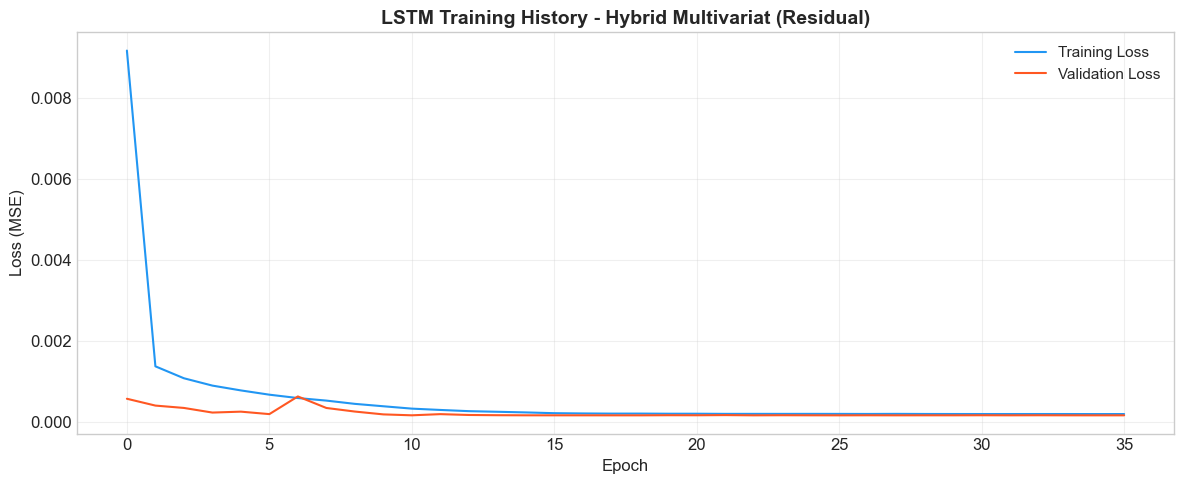

Best epoch: 26
Best val_loss: 0.000160


In [114]:
# Plot training history
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history_multi.history['loss'], label='Training Loss', color='#2196F3', linewidth=1.5)
ax.plot(history_multi.history['val_loss'], label='Validation Loss', color='#FF5722', linewidth=1.5)
ax.set_title('LSTM Training History - Hybrid Multivariat (Residual)', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_training_hybrid_multi.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best epoch: {np.argmin(history_multi.history['val_loss']) + 1}")
print(f"Best val_loss: {min(history_multi.history['val_loss']):.6f}")

### 5.3 Penggabungan Model Hybrid (Multivariat)

$$\hat{y}_t = \hat{L}_t^{\text{SARIMAX}} + \hat{N}_t^{\text{LSTM}}$$

In [115]:
# Predict residuals using LSTM
resid_pred_multi_scaled = lstm_resid_multi.predict(X_resid_test_multi)
resid_pred_multi = scaler_resid_multi.inverse_transform(resid_pred_multi_scaled).flatten()

# Align predictions
n_pred = min(len(sarimax_multi_pred), len(resid_pred_multi))
test_aligned_multi = test_endog.iloc[:n_pred]
sarimax_pred_aligned_multi = sarimax_multi_pred.iloc[:n_pred]

# Hybrid prediction = SARIMAX linear + LSTM non-linear
hybrid_multi_pred = sarimax_pred_aligned_multi.values + resid_pred_multi[:n_pred]

print(f"Hybrid Multivariat predictions: {len(hybrid_multi_pred)} values")
print(f"Test aligned period: {test_aligned_multi.index[0].date()} to {test_aligned_multi.index[-1].date()}")

# Evaluate Hybrid Multivariate
hybrid_multi_metrics = calculate_metrics(
    test_aligned_multi.values, hybrid_multi_pred,
    'Hybrid SARIMAX-LSTM Multivariat'
)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Hybrid Multivariat predictions: 426 values
Test aligned period: 2024-09-12 to 2026-04-30

Evaluasi Model: Hybrid SARIMAX-LSTM Multivariat
  RMSE : 94.9723
  MAE  : 64.5732
  MAPE : 0.8753%
  → Kemampuan peramalan: SANGAT BAIK (MAPE < 10%)


---
## 6. Skenario 2: Model Hybrid SARIMAX-LSTM Univariat

Model ini menggunakan SARIMAX **tanpa variabel eksogen** (univariat), kemudian residualnya dimodelkan dengan LSTM.

### 6.1 Pemodelan SARIMAX Univariat

In [116]:
%%time

# Grid search for univariate SARIMAX
best_aic_uni = np.inf
best_order_uni = None
results_grid_uni = []

print("Grid Search SARIMAX (Univariat) - Mencari parameter optimal...")
print("="*60)

for p, d, q in itertools.product(p_range, d_range, q_range):
    try:
        model = SARIMAX(
            train_endog,
            order=(p, d, q),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fitted = model.fit(disp=False, maxiter=200)
        aic = fitted.aic
        results_grid_uni.append({'order': (p, d, q), 'AIC': aic})
        
        if aic < best_aic_uni:
            best_aic_uni = aic
            best_order_uni = (p, d, q)
            print(f"  ✓ New best: order={best_order_uni}, AIC={best_aic_uni:.2f}")
    except Exception as e:
        continue

print(f"\n{'='*60}")
print(f"Parameter SARIMAX Univariat terbaik:")
print(f"  Order (p,d,q) = {best_order_uni}")
print(f"  AIC           = {best_aic_uni:.2f}")

Grid Search SARIMAX (Univariat) - Mencari parameter optimal...
  ✓ New best: order=(0, 0, 0), AIC=76896.73
  ✓ New best: order=(0, 0, 1), AIC=74020.10
  ✓ New best: order=(0, 0, 2), AIC=67258.61
  ✓ New best: order=(0, 1, 0), AIC=40808.76
  ✓ New best: order=(0, 1, 1), AIC=40799.24
  ✓ New best: order=(0, 1, 2), AIC=40790.06

Parameter SARIMAX Univariat terbaik:
  Order (p,d,q) = (0, 1, 2)
  AIC           = 40790.06
CPU times: user 1.97 s, sys: 14.5 ms, total: 1.98 s
Wall time: 1.99 s


In [117]:
# Fit the best SARIMAX model (Univariate)
print(f"Fitting SARIMAX Univariat with order={best_order_uni}...")

sarimax_uni_model = SARIMAX(
    train_endog,
    order=best_order_uni,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_uni_fitted = sarimax_uni_model.fit(disp=False, maxiter=500)

print(sarimax_uni_fitted.summary())

Fitting SARIMAX Univariat with order=(0, 1, 2)...
                               SARIMAX Results                                
Dep. Variable:                   IHSG   No. Observations:                 3834
Model:               SARIMAX(0, 1, 2)   Log Likelihood              -20392.030
Date:                Sat, 06 Jun 2026   AIC                          40790.059
Time:                        13:49:33   BIC                          40808.811
Sample:                    01-01-2010   HQIC                         40796.721
                         - 09-11-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0192      0.011      1.696      0.090      -0.003       0.041
ma.L2         -0.0206      0.012     -1.768      0.077      -0.043       0.002
si

In [118]:
# ================================================================
# ROLLING ONE-STEP-AHEAD PREDICTION for SARIMAX Univariate
# ================================================================

print("Rolling one-step-ahead prediction (SARIMAX Univariat)...")
print(f"Predicting {len(test_data)} steps...\n")

sarimax_uni_rolling_preds = []
current_result_uni = sarimax_uni_fitted

for t in tqdm(range(len(test_data)), desc="SARIMAX Uni Rolling"):
    # Predict one step ahead
    fc = current_result_uni.forecast(steps=1)
    sarimax_uni_rolling_preds.append(fc.values[0])
    
    # Extend model with actual observation (no refit)
    current_result_uni = current_result_uni.append(
        endog=[test_endog.iloc[t]],
        refit=False
    )

sarimax_uni_pred = pd.Series(
    sarimax_uni_rolling_preds,
    index=test_data.index,
    name='SARIMAX_Uni_Pred'
)

print(f"\n✓ Rolling predictions completed: {len(sarimax_uni_pred)} values")

Rolling one-step-ahead prediction (SARIMAX Univariat)...
Predicting 426 steps...



SARIMAX Uni Rolling: 100%|██████████| 426/426 [00:34<00:00, 12.26it/s]


✓ Rolling predictions completed: 426 values


In [119]:
# Residuals
sarimax_uni_train_pred = sarimax_uni_fitted.fittedvalues
residuals_uni_train = train_endog - sarimax_uni_train_pred
residuals_uni_test = test_endog - sarimax_uni_pred

# Evaluate standalone SARIMAX Univariate
sarimax_uni_metrics = calculate_metrics(test_endog, sarimax_uni_pred, 'SARIMAX Univariat (standalone)')


Evaluasi Model: SARIMAX Univariat (standalone)
  RMSE : 92.5426
  MAE  : 61.4846
  MAPE : 0.8325%
  → Kemampuan peramalan: SANGAT BAIK (MAPE < 10%)


### 6.2 Pemodelan LSTM untuk Residual (Univariat)

In [120]:
# Scale and prepare residuals for univariate model
scaler_resid_uni = MinMaxScaler(feature_range=(0, 1))

resid_uni_train_scaled = scaler_resid_uni.fit_transform(
    residuals_uni_train.values.reshape(-1, 1)
)
resid_uni_test_scaled = scaler_resid_uni.transform(
    residuals_uni_test.values.reshape(-1, 1)
)

combined_resid_uni_scaled = np.concatenate([resid_uni_train_scaled, resid_uni_test_scaled])

# Create sequences
X_resid_train_uni, y_resid_train_uni = create_lstm_sequences(resid_uni_train_scaled, LOOK_BACK)

test_input_uni = combined_resid_uni_scaled[len(resid_uni_train_scaled) - LOOK_BACK:]
X_resid_test_uni, y_resid_test_uni = create_lstm_sequences(test_input_uni, LOOK_BACK)

print(f"Univariat - Training sequences: X={X_resid_train_uni.shape}, y={y_resid_train_uni.shape}")
print(f"Univariat - Testing sequences : X={X_resid_test_uni.shape}, y={y_resid_test_uni.shape}")

Univariat - Training sequences: X=(3804, 30, 1), y=(3804,)
Univariat - Testing sequences : X=(426, 30, 1), y=(426,)


In [121]:
# Build and train LSTM for univariate residuals
print("Training LSTM for Hybrid SARIMAX-LSTM Univariat residuals...\n")

lstm_resid_uni = build_lstm_model(LOOK_BACK, LSTM_UNITS, DROPOUT_RATE, LEARNING_RATE)

early_stop_uni = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_uni = lstm_resid_uni.fit(
    X_resid_train_uni, y_resid_train_uni,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=[early_stop_uni],
    verbose=1
)

Training LSTM for Hybrid SARIMAX-LSTM Univariat residuals...

Epoch 1/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 8.7597e-04 - val_loss: 2.5558e-04
Epoch 2/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.5302e-04 - val_loss: 2.4915e-04
Epoch 3/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.3611e-04 - val_loss: 2.5368e-04
Epoch 4/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.2210e-04 - val_loss: 2.4812e-04
Epoch 5/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.1248e-04 - val_loss: 2.4783e-04
Epoch 6/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.0686e-04 - val_loss: 2.4784e-04
Epoch 7/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.0520e-04 - val_loss: 2.4945e-04
Epoch 8/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.0655e-04 - val_loss: 2.4777e-04
Epoch 9/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.0280e-04 - val_loss: 2.4793e-04
Epoch 10/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.0093e-04 - val_loss

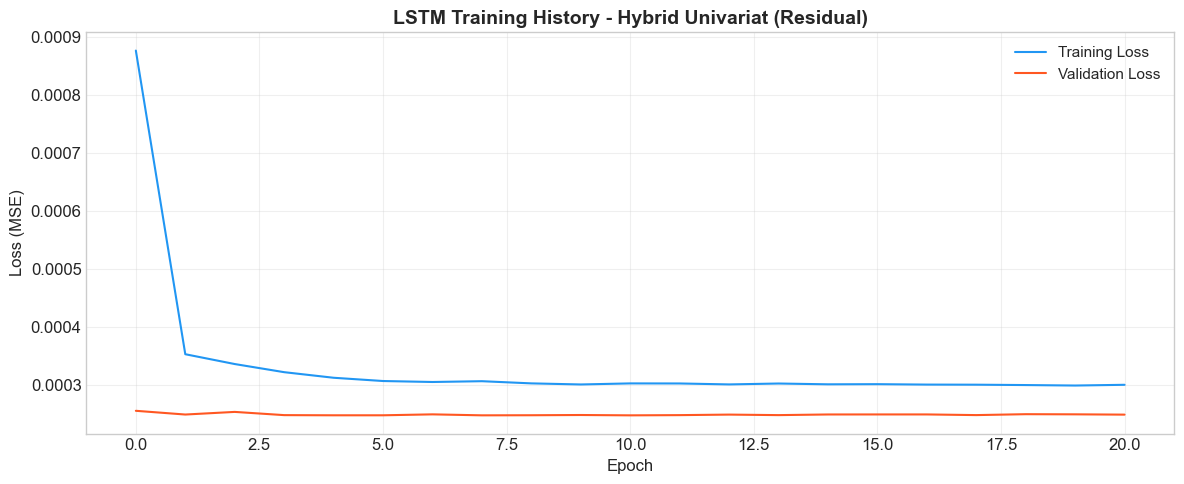

In [122]:
# Plot training history - Univariate
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history_uni.history['loss'], label='Training Loss', color='#2196F3', linewidth=1.5)
ax.plot(history_uni.history['val_loss'], label='Validation Loss', color='#FF5722', linewidth=1.5)
ax.set_title('LSTM Training History - Hybrid Univariat (Residual)', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_training_hybrid_uni.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Penggabungan Model Hybrid (Univariat)

In [123]:
# Predict residuals
resid_pred_uni_scaled = lstm_resid_uni.predict(X_resid_test_uni)
resid_pred_uni = scaler_resid_uni.inverse_transform(resid_pred_uni_scaled).flatten()

# Align
n_pred_uni = min(len(sarimax_uni_pred), len(resid_pred_uni))
test_aligned_uni = test_endog.iloc[:n_pred_uni]
sarimax_pred_aligned_uni = sarimax_uni_pred.iloc[:n_pred_uni]

hybrid_uni_pred = sarimax_pred_aligned_uni.values + resid_pred_uni[:n_pred_uni]

# Evaluate Hybrid Univariate
hybrid_uni_metrics = calculate_metrics(
    test_aligned_uni.values, hybrid_uni_pred,
    'Hybrid SARIMAX-LSTM Univariat'
)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Evaluasi Model: Hybrid SARIMAX-LSTM Univariat
  RMSE : 92.6249
  MAE  : 61.6123
  MAPE : 0.8343%
  → Kemampuan peramalan: SANGAT BAIK (MAPE < 10%)


---
## 7. Skenario 3: Model LSTM Tunggal

Model LSTM standalone yang langsung memprediksi harga penutupan IHSG (tanpa SARIMAX).

In [124]:
# Scale IHSG data for standalone LSTM
scaler_ihsg = MinMaxScaler(feature_range=(0, 1))

train_ihsg_scaled = scaler_ihsg.fit_transform(train_data['IHSG'].values.reshape(-1, 1))
test_ihsg_scaled = scaler_ihsg.transform(test_data['IHSG'].values.reshape(-1, 1))

combined_ihsg_scaled = np.concatenate([train_ihsg_scaled, test_ihsg_scaled])

# Create sequences
X_train_lstm, y_train_lstm = create_lstm_sequences(train_ihsg_scaled, LOOK_BACK)

test_input_lstm = combined_ihsg_scaled[len(train_ihsg_scaled) - LOOK_BACK:]
X_test_lstm, y_test_lstm = create_lstm_sequences(test_input_lstm, LOOK_BACK)

print(f"Standalone LSTM - Training sequences: X={X_train_lstm.shape}, y={y_train_lstm.shape}")
print(f"Standalone LSTM - Testing sequences : X={X_test_lstm.shape}, y={y_test_lstm.shape}")

Standalone LSTM - Training sequences: X=(3804, 30, 1), y=(3804,)
Standalone LSTM - Testing sequences : X=(426, 30, 1), y=(426,)


In [125]:
# Build and train standalone LSTM
print("Training LSTM Tunggal (Standalone)...\n")

lstm_standalone = build_lstm_model(LOOK_BACK, LSTM_UNITS, DROPOUT_RATE, LEARNING_RATE)
lstm_standalone.summary()

early_stop_sa = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_sa = lstm_standalone.fit(
    X_train_lstm, y_train_lstm,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=[early_stop_sa],
    verbose=1
)

Training LSTM Tunggal (Standalone)...



Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0155 - val_loss: 0.0039
Epoch 2/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0026 - val_loss: 0.0047
Epoch 3/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0021 - val_loss: 0.0018
Epoch 4/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0019 - val_loss: 0.0099
Epoch 5/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0019 - val_loss: 0.0060
Epoch 6/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0015 - val_loss: 0.0051
Epoch 7/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0013 - val_loss: 0.0094
Epoch 8/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0013 - val_loss: 0.0068
Epoch 9/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0012 - val_loss: 0.0044
Epoch 10/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.7512e-04 - val_loss: 0.0045
Epoch 11/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.8926e-04 - val_loss: 0.0131
Epoch 12/100
102/102 ━━━━━━━━━━━━

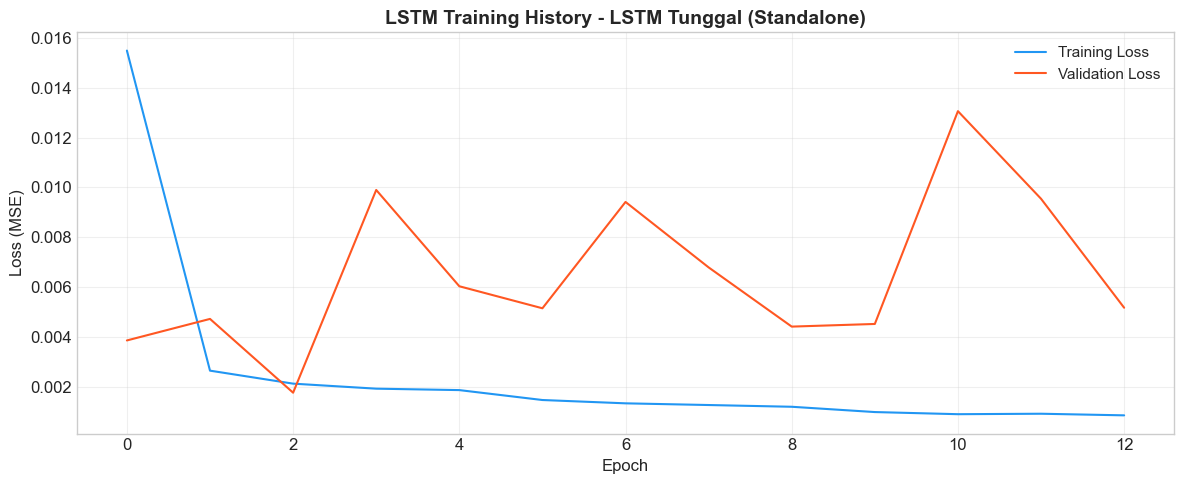

In [126]:
# Plot training history - Standalone LSTM
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history_sa.history['loss'], label='Training Loss', color='#2196F3', linewidth=1.5)
ax.plot(history_sa.history['val_loss'], label='Validation Loss', color='#FF5722', linewidth=1.5)
ax.set_title('LSTM Training History - LSTM Tunggal (Standalone)', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_training_standalone.png', dpi=150, bbox_inches='tight')
plt.show()

In [127]:
# Standalone LSTM predictions
lstm_pred_scaled = lstm_standalone.predict(X_test_lstm)
lstm_pred = scaler_ihsg.inverse_transform(lstm_pred_scaled).flatten()

# Align with test data
n_pred_lstm = min(len(test_endog), len(lstm_pred))
test_aligned_lstm = test_endog.iloc[:n_pred_lstm]

# Evaluate Standalone LSTM
lstm_standalone_metrics = calculate_metrics(
    test_aligned_lstm.values, lstm_pred[:n_pred_lstm],
    'LSTM Tunggal (Standalone)'
)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Evaluasi Model: LSTM Tunggal (Standalone)
  RMSE : 339.0763
  MAE  : 292.6991
  MAPE : 3.8004%
  → Kemampuan peramalan: SANGAT BAIK (MAPE < 10%)


---
## 8. Perbandingan dan Evaluasi Model

In [128]:
# Compile all results
comparison_data = {
    'Hybrid SARIMAX-LSTM\nMultivariat': hybrid_multi_metrics,
    'Hybrid SARIMAX-LSTM\nUnivariat': hybrid_uni_metrics,
    'LSTM Tunggal': lstm_standalone_metrics
}

comparison_df = pd.DataFrame(comparison_data).T
comparison_df.index.name = 'Model'
comparison_df = comparison_df.round(4)

print("\n" + "=" * 70)
print("PERBANDINGAN KINERJA MODEL")
print("=" * 70)
print(comparison_df.to_string())

# Find best model
best_rmse = comparison_df['RMSE'].idxmin()
best_mae = comparison_df['MAE'].idxmin()
best_mape = comparison_df['MAPE'].idxmin()

print(f"\n{'='*70}")
print(f"Model terbaik berdasarkan RMSE : {best_rmse}")
print(f"Model terbaik berdasarkan MAE  : {best_mae}")
print(f"Model terbaik berdasarkan MAPE : {best_mape}")


PERBANDINGAN KINERJA MODEL
                                      RMSE       MAE    MAPE
Model                                                       
Hybrid SARIMAX-LSTM\nMultivariat   94.9723   64.5732  0.8753
Hybrid SARIMAX-LSTM\nUnivariat     92.6249   61.6123  0.8343
LSTM Tunggal                      339.0763  292.6991  3.8004

Model terbaik berdasarkan RMSE : Hybrid SARIMAX-LSTM
Univariat
Model terbaik berdasarkan MAE  : Hybrid SARIMAX-LSTM
Univariat
Model terbaik berdasarkan MAPE : Hybrid SARIMAX-LSTM
Univariat


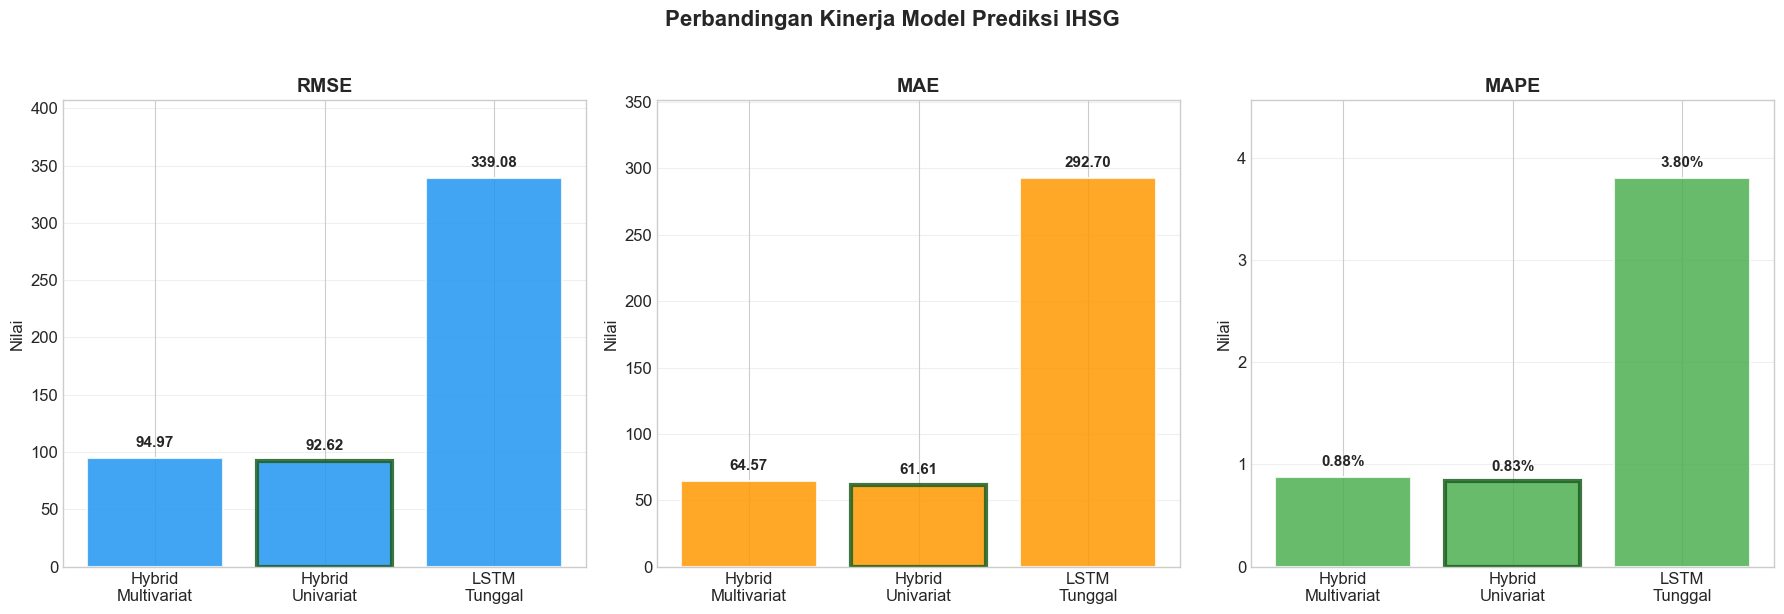

In [129]:
# Visualization: Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Perbandingan Kinerja Model Prediksi IHSG', fontsize=16, fontweight='bold', y=1.02)

metrics = ['RMSE', 'MAE', 'MAPE']
colors_bar = ['#2196F3', '#FF9800', '#4CAF50']
model_labels = ['Hybrid\nMultivariat', 'Hybrid\nUnivariat', 'LSTM\nTunggal']

for ax, metric, color in zip(axes, metrics, colors_bar):
    values = comparison_df[metric].values
    bars = ax.bar(model_labels, values, color=color, alpha=0.85, edgecolor='white', linewidth=1.5)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        suffix = '%' if metric == 'MAPE' else ''
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(values)*0.02,
                f'{val:.2f}{suffix}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Highlight best (lowest) bar
    best_idx = np.argmin(values)
    bars[best_idx].set_edgecolor('#1B5E20')
    bars[best_idx].set_linewidth(3)
    
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_ylabel('Nilai')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(values) * 1.2)

plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [130]:
# Display comparison table nicely
comparison_display = comparison_df.copy()
comparison_display.index = ['Hybrid SARIMAX-LSTM Multivariat', 'Hybrid SARIMAX-LSTM Univariat', 'LSTM Tunggal']
comparison_display['MAPE'] = comparison_display['MAPE'].apply(lambda x: f"{x:.4f}%")
comparison_display

,RMSE,MAE,MAPE
Hybrid SARIMAX-LSTM Multivariat,94.9723,64.5732,0.8753%
Hybrid SARIMAX-LSTM Univariat,92.6249,61.6123,0.8343%
LSTM Tunggal,339.0763,292.6991,3.8004%


---
## 9. Visualisasi Prediksi

In [131]:
# Align all predictions to the same test period for comparison
n_common = min(len(test_aligned_multi), len(test_aligned_uni), len(test_aligned_lstm))
common_idx = test_aligned_multi.index[:n_common]
actual_common = test_endog.loc[common_idx]

hybrid_multi_common = hybrid_multi_pred[:n_common]
hybrid_uni_common = hybrid_uni_pred[:n_common]
lstm_sa_common = lstm_pred[:n_common]

print(f"Common comparison period: {common_idx[0].date()} to {common_idx[-1].date()}")
print(f"Number of data points: {len(common_idx)}")

Common comparison period: 2024-09-12 to 2026-04-30
Number of data points: 426


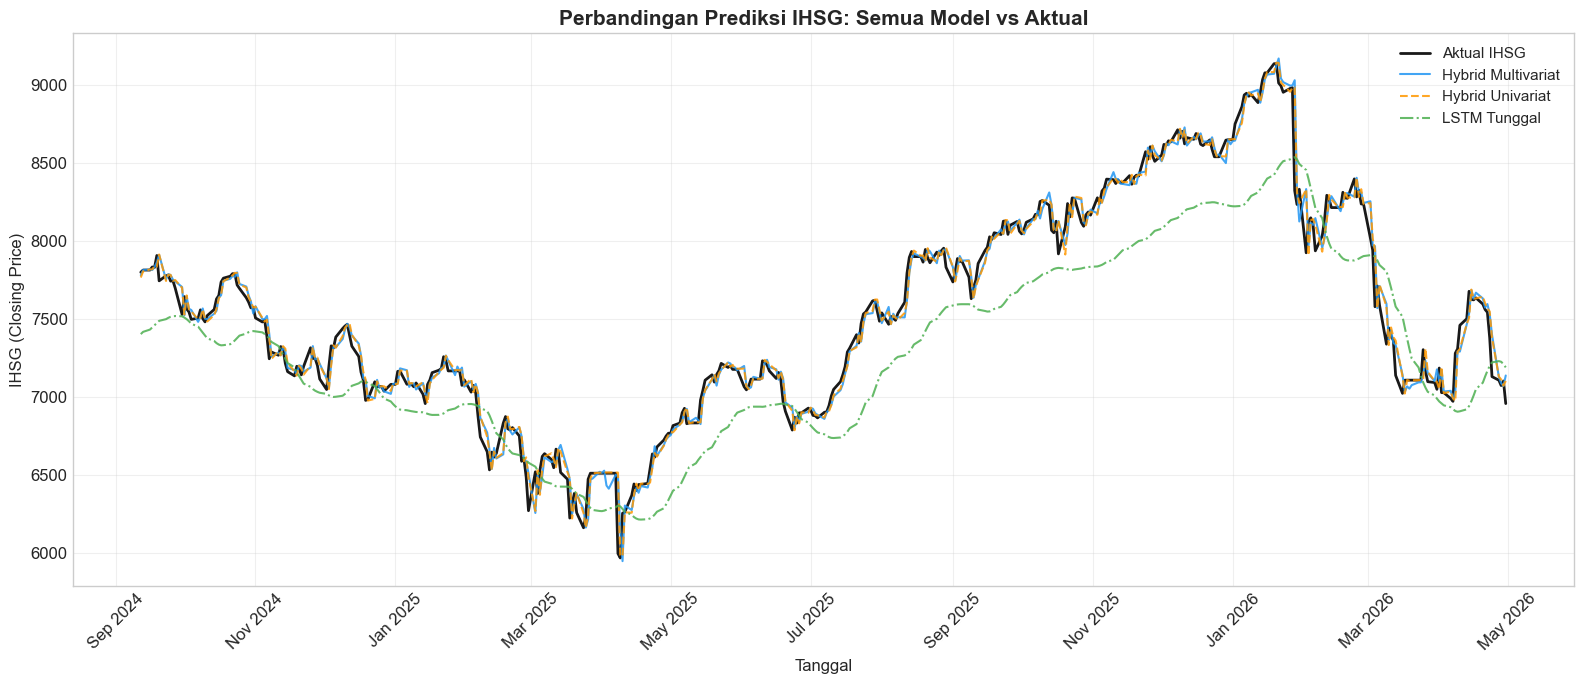

In [132]:
# Plot 1: All models vs actual
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(common_idx, actual_common, color='black', linewidth=2, label='Aktual IHSG', alpha=0.9)
ax.plot(common_idx, hybrid_multi_common, color='#2196F3', linewidth=1.5,
        label='Hybrid Multivariat', linestyle='-', alpha=0.85)
ax.plot(common_idx, hybrid_uni_common, color='#FF9800', linewidth=1.5,
        label='Hybrid Univariat', linestyle='--', alpha=0.85)
ax.plot(common_idx, lstm_sa_common, color='#4CAF50', linewidth=1.5,
        label='LSTM Tunggal', linestyle='-.', alpha=0.85)

ax.set_title('Perbandingan Prediksi IHSG: Semua Model vs Aktual', fontsize=15, fontweight='bold')
ax.set_xlabel('Tanggal', fontsize=12)
ax.set_ylabel('IHSG (Closing Price)', fontsize=12)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('prediction_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()

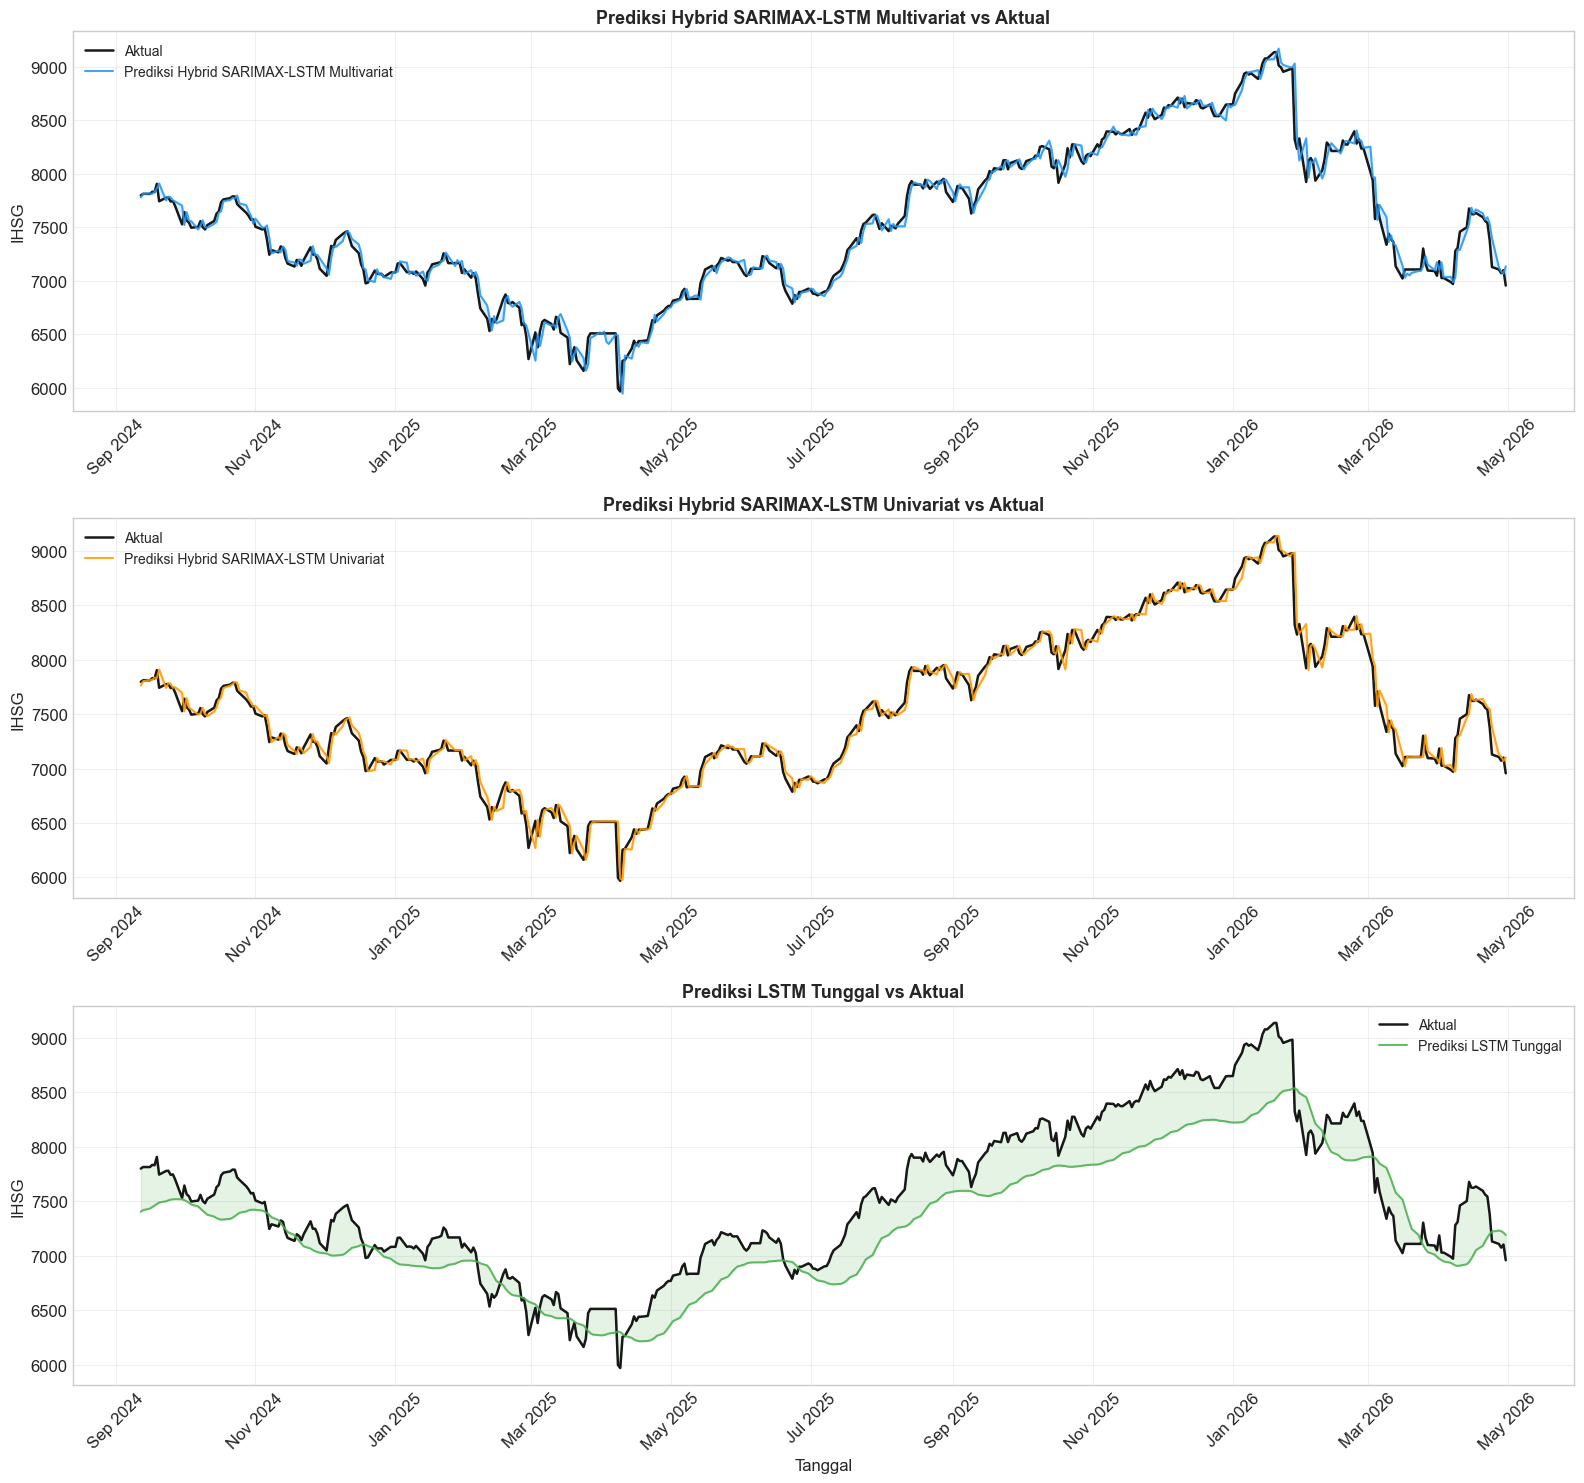

In [133]:
# Plot 2: Individual model predictions
fig, axes = plt.subplots(3, 1, figsize=(16, 15))

models_data = [
    ('Hybrid SARIMAX-LSTM Multivariat', hybrid_multi_common, '#2196F3'),
    ('Hybrid SARIMAX-LSTM Univariat', hybrid_uni_common, '#FF9800'),
    ('LSTM Tunggal', lstm_sa_common, '#4CAF50')
]

for ax, (name, pred, color) in zip(axes, models_data):
    ax.plot(common_idx, actual_common, color='black', linewidth=1.8, label='Aktual', alpha=0.9)
    ax.plot(common_idx, pred, color=color, linewidth=1.5, label=f'Prediksi {name}', alpha=0.85)
    ax.fill_between(common_idx, actual_common, pred, alpha=0.15, color=color)
    ax.set_title(f'Prediksi {name} vs Aktual', fontsize=13, fontweight='bold')
    ax.set_ylabel('IHSG')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=45)

axes[-1].set_xlabel('Tanggal')
plt.tight_layout()
plt.savefig('prediction_individual.png', dpi=150, bbox_inches='tight')
plt.show()

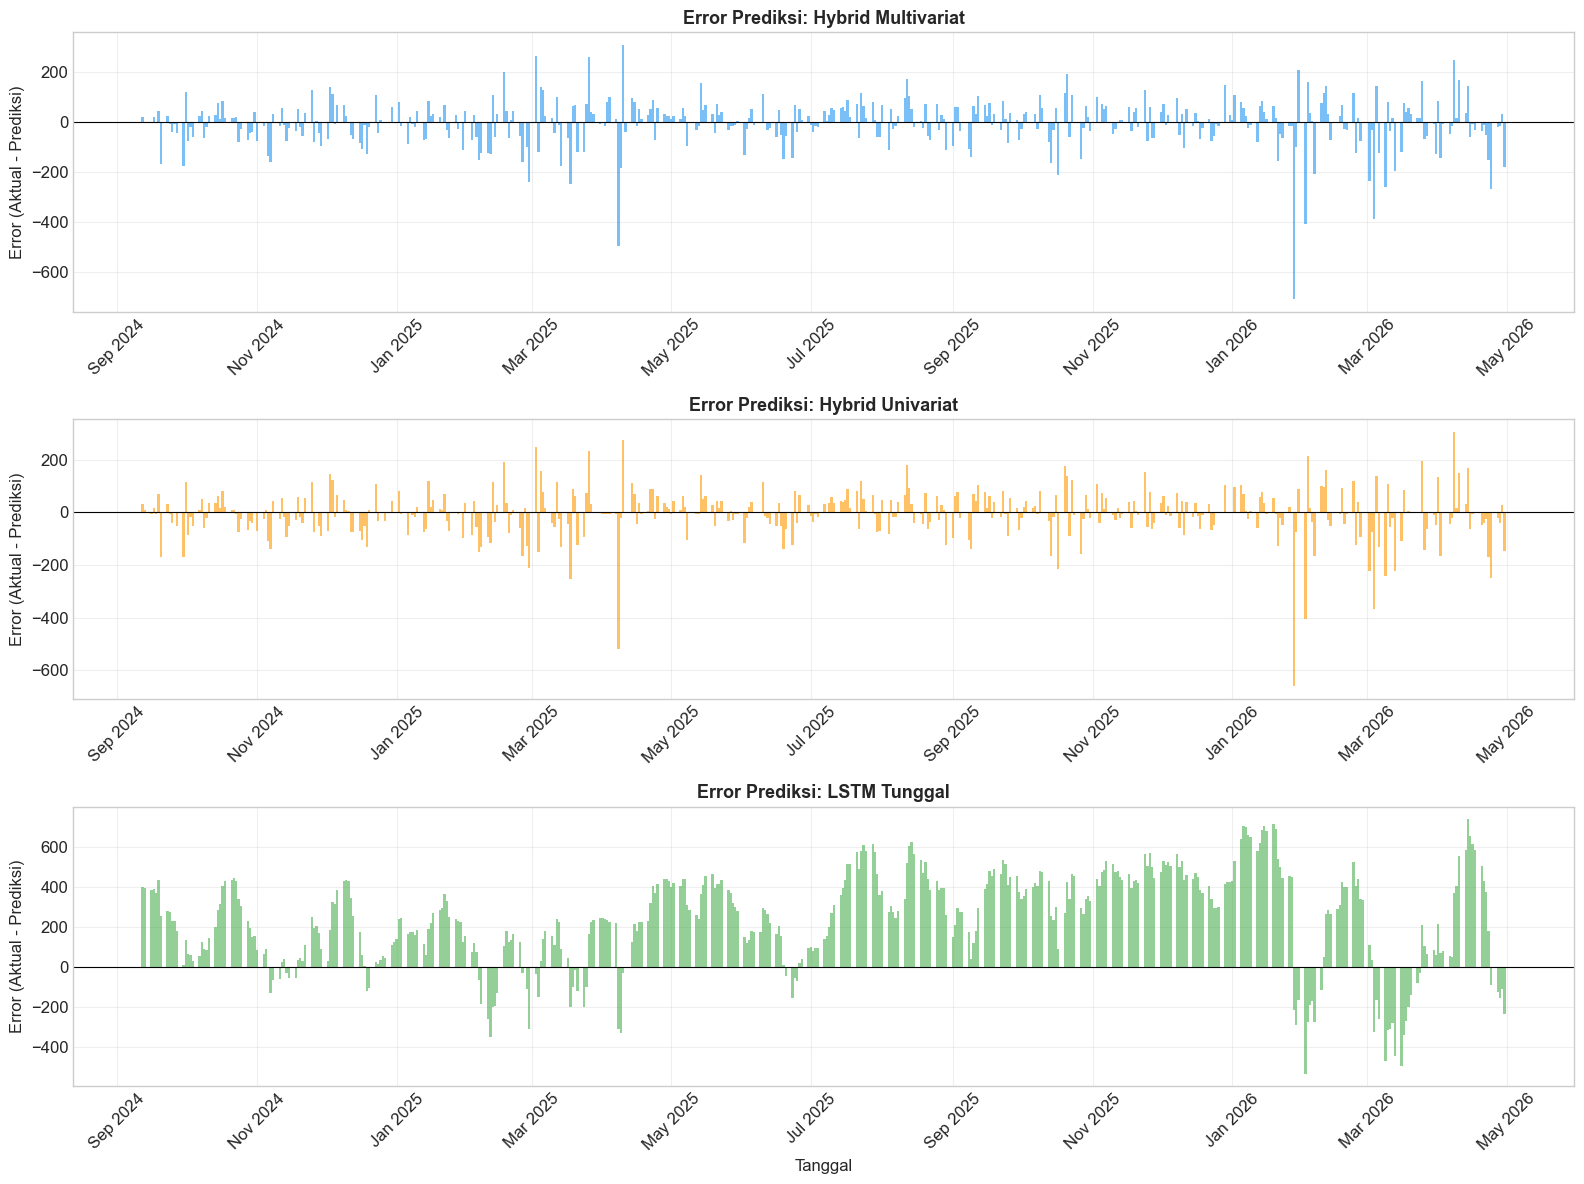

In [134]:
# Plot 3: Prediction error comparison
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

errors = [
    ('Hybrid Multivariat', actual_common.values - hybrid_multi_common, '#2196F3'),
    ('Hybrid Univariat', actual_common.values - hybrid_uni_common, '#FF9800'),
    ('LSTM Tunggal', actual_common.values - lstm_sa_common, '#4CAF50')
]

for ax, (name, error, color) in zip(axes, errors):
    ax.bar(common_idx, error, color=color, alpha=0.6, width=1)
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_title(f'Error Prediksi: {name}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Error (Aktual - Prediksi)')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=45)

axes[-1].set_xlabel('Tanggal')
plt.tight_layout()
plt.savefig('prediction_errors.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Error Distribution Analysis

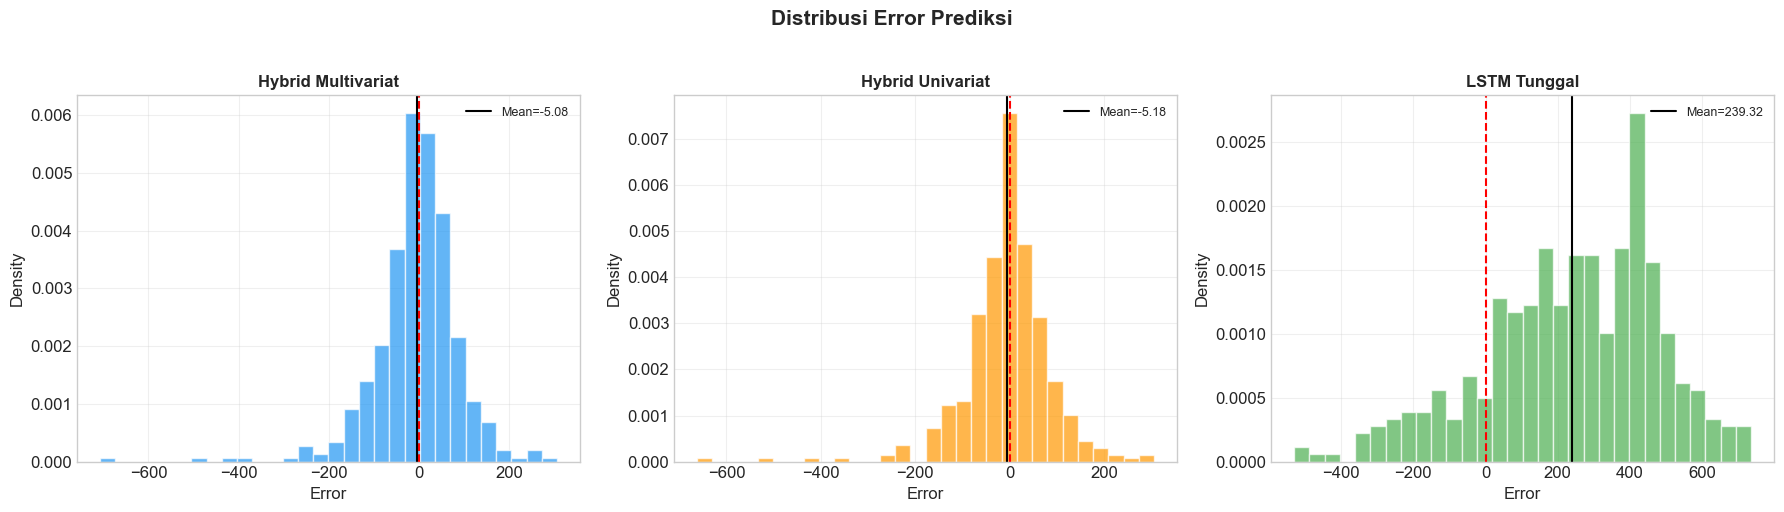

In [135]:
# Error distribution histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribusi Error Prediksi', fontsize=15, fontweight='bold', y=1.02)

for ax, (name, error, color) in zip(axes, errors):
    ax.hist(error, bins=30, color=color, alpha=0.7, edgecolor='white', density=True)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
    ax.axvline(x=np.mean(error), color='black', linestyle='-', linewidth=1.5, label=f'Mean={np.mean(error):.2f}')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Error')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Scatter Plot: Actual vs Predicted

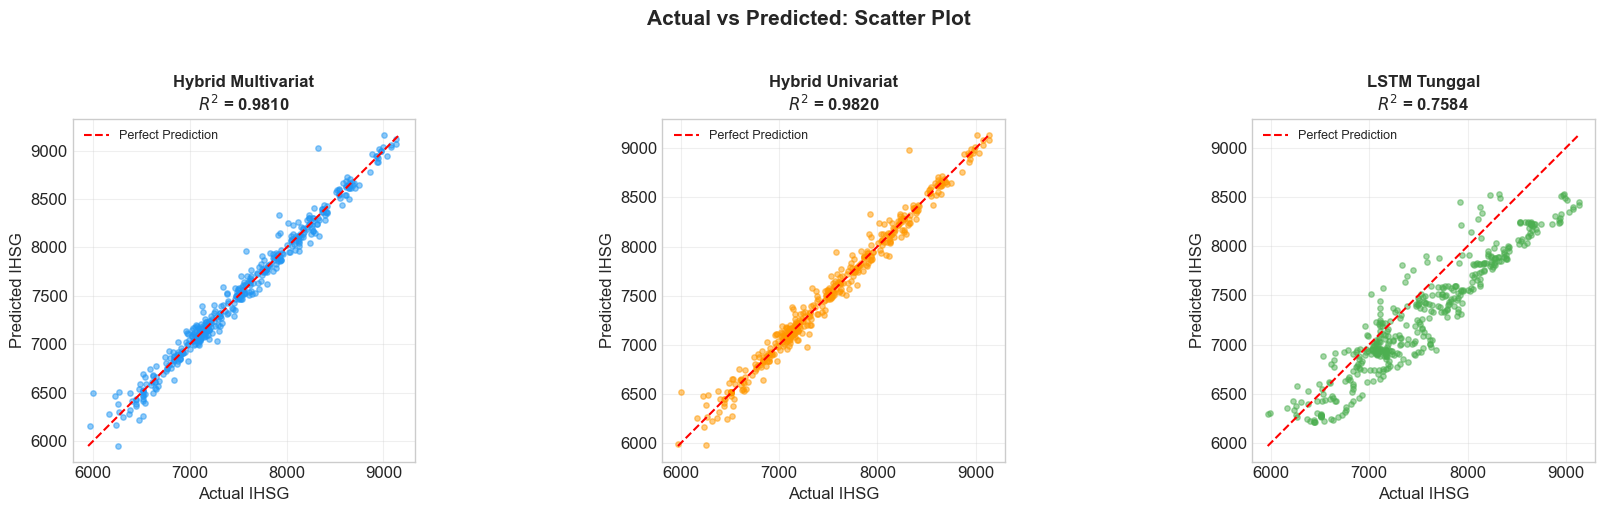

In [136]:
# Scatter plots: Actual vs Predicted
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Actual vs Predicted: Scatter Plot', fontsize=15, fontweight='bold', y=1.02)

preds_list = [
    ('Hybrid Multivariat', hybrid_multi_common, '#2196F3'),
    ('Hybrid Univariat', hybrid_uni_common, '#FF9800'),
    ('LSTM Tunggal', lstm_sa_common, '#4CAF50')
]

for ax, (name, pred, color) in zip(axes, preds_list):
    ax.scatter(actual_common.values, pred, alpha=0.5, s=15, color=color)
    
    # Perfect prediction line
    min_val = min(actual_common.min(), np.min(pred))
    max_val = max(actual_common.max(), np.max(pred))
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
    
    # R-squared
    ss_res = np.sum((actual_common.values - pred) ** 2)
    ss_tot = np.sum((actual_common.values - np.mean(actual_common.values)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    
    ax.set_title(f'{name}\n$R^2$ = {r2:.4f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual IHSG')
    ax.set_ylabel('Predicted IHSG')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('scatter_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Ringkasan dan Kesimpulan

In [137]:
# Final summary
print("="*70)
print("RINGKASAN HASIL PENELITIAN")
print("Implementasi Model Hybrid SARIMAX-LSTM dengan")
print("Multiple Exogenous Variables untuk Prediksi IHSG")
print("="*70)

print(f"\nPeriode Data  : {START_DATE} s.d. {END_DATE}")
print(f"Total Data    : {len(df)} hari perdagangan")
print(f"Data Training : {len(train_data)} ({len(train_data)/len(df)*100:.0f}%)")
print(f"Data Testing  : {len(test_data)} ({len(test_data)/len(df)*100:.0f}%)")

print(f"\nVariabel Eksogen:")
print(f"  1. Kurs USD/IDR")
print(f"  2. Harga Emas (XAU/USD)")
print(f"  3. Indeks S&P 500")

print(f"\n{'='*70}")
print(f"{'Model':<42} {'RMSE':>10} {'MAE':>10} {'MAPE':>10}")
print(f"{'-'*70}")

summary_models = [
    ('Hybrid SARIMAX-LSTM Multivariat', hybrid_multi_metrics),
    ('Hybrid SARIMAX-LSTM Univariat', hybrid_uni_metrics),
    ('LSTM Tunggal', lstm_standalone_metrics)
]

for name, metrics_dict in summary_models:
    print(f"{name:<42} {metrics_dict['RMSE']:>10.4f} {metrics_dict['MAE']:>10.4f} {metrics_dict['MAPE']:>9.4f}%")

print(f"{'-'*70}")

# Determine overall best model
all_metrics = {name: m for name, m in summary_models}
best_model = min(all_metrics.items(), key=lambda x: x[1]['MAPE'])

print(f"\n✅ Model terbaik berdasarkan MAPE: {best_model[0]}")
print(f"   RMSE = {best_model[1]['RMSE']:.4f}")
print(f"   MAE  = {best_model[1]['MAE']:.4f}")
print(f"   MAPE = {best_model[1]['MAPE']:.4f}%")

# Check improvements
if hybrid_multi_metrics['MAPE'] < lstm_standalone_metrics['MAPE']:
    improvement = ((lstm_standalone_metrics['MAPE'] - hybrid_multi_metrics['MAPE']) / lstm_standalone_metrics['MAPE']) * 100
    print(f"\n📊 Hybrid Multivariat menunjukkan peningkatan {improvement:.2f}% dibandingkan LSTM Tunggal (berdasarkan MAPE)")

if hybrid_multi_metrics['MAPE'] < hybrid_uni_metrics['MAPE']:
    improvement = ((hybrid_uni_metrics['MAPE'] - hybrid_multi_metrics['MAPE']) / hybrid_uni_metrics['MAPE']) * 100
    print(f"📊 Penambahan variabel eksogen meningkatkan akurasi {improvement:.2f}% dibandingkan model univariat (berdasarkan MAPE)")

if hybrid_uni_metrics['MAPE'] < lstm_standalone_metrics['MAPE']:
    improvement = ((lstm_standalone_metrics['MAPE'] - hybrid_uni_metrics['MAPE']) / lstm_standalone_metrics['MAPE']) * 100
    print(f"📊 Hybrid Univariat menunjukkan peningkatan {improvement:.2f}% dibandingkan LSTM Tunggal (berdasarkan MAPE)")

RINGKASAN HASIL PENELITIAN
Implementasi Model Hybrid SARIMAX-LSTM dengan
Multiple Exogenous Variables untuk Prediksi IHSG

Periode Data  : 2010-01-01 s.d. 2026-05-01
Total Data    : 4260 hari perdagangan
Data Training : 3834 (90%)
Data Testing  : 426 (10%)

Variabel Eksogen:
  1. Kurs USD/IDR
  2. Harga Emas (XAU/USD)
  3. Indeks S&P 500

Model                                            RMSE        MAE       MAPE
----------------------------------------------------------------------
Hybrid SARIMAX-LSTM Multivariat               94.9723    64.5732    0.8753%
Hybrid SARIMAX-LSTM Univariat                 92.6249    61.6123    0.8343%
LSTM Tunggal                                 339.0763   292.6991    3.8004%
----------------------------------------------------------------------

✅ Model terbaik berdasarkan MAPE: Hybrid SARIMAX-LSTM Univariat
   RMSE = 92.6249
   MAE  = 61.6123
   MAPE = 0.8343%

📊 Hybrid Multivariat menunjukkan peningkatan 76.97% dibandingkan LSTM Tunggal (berdasarkan MA

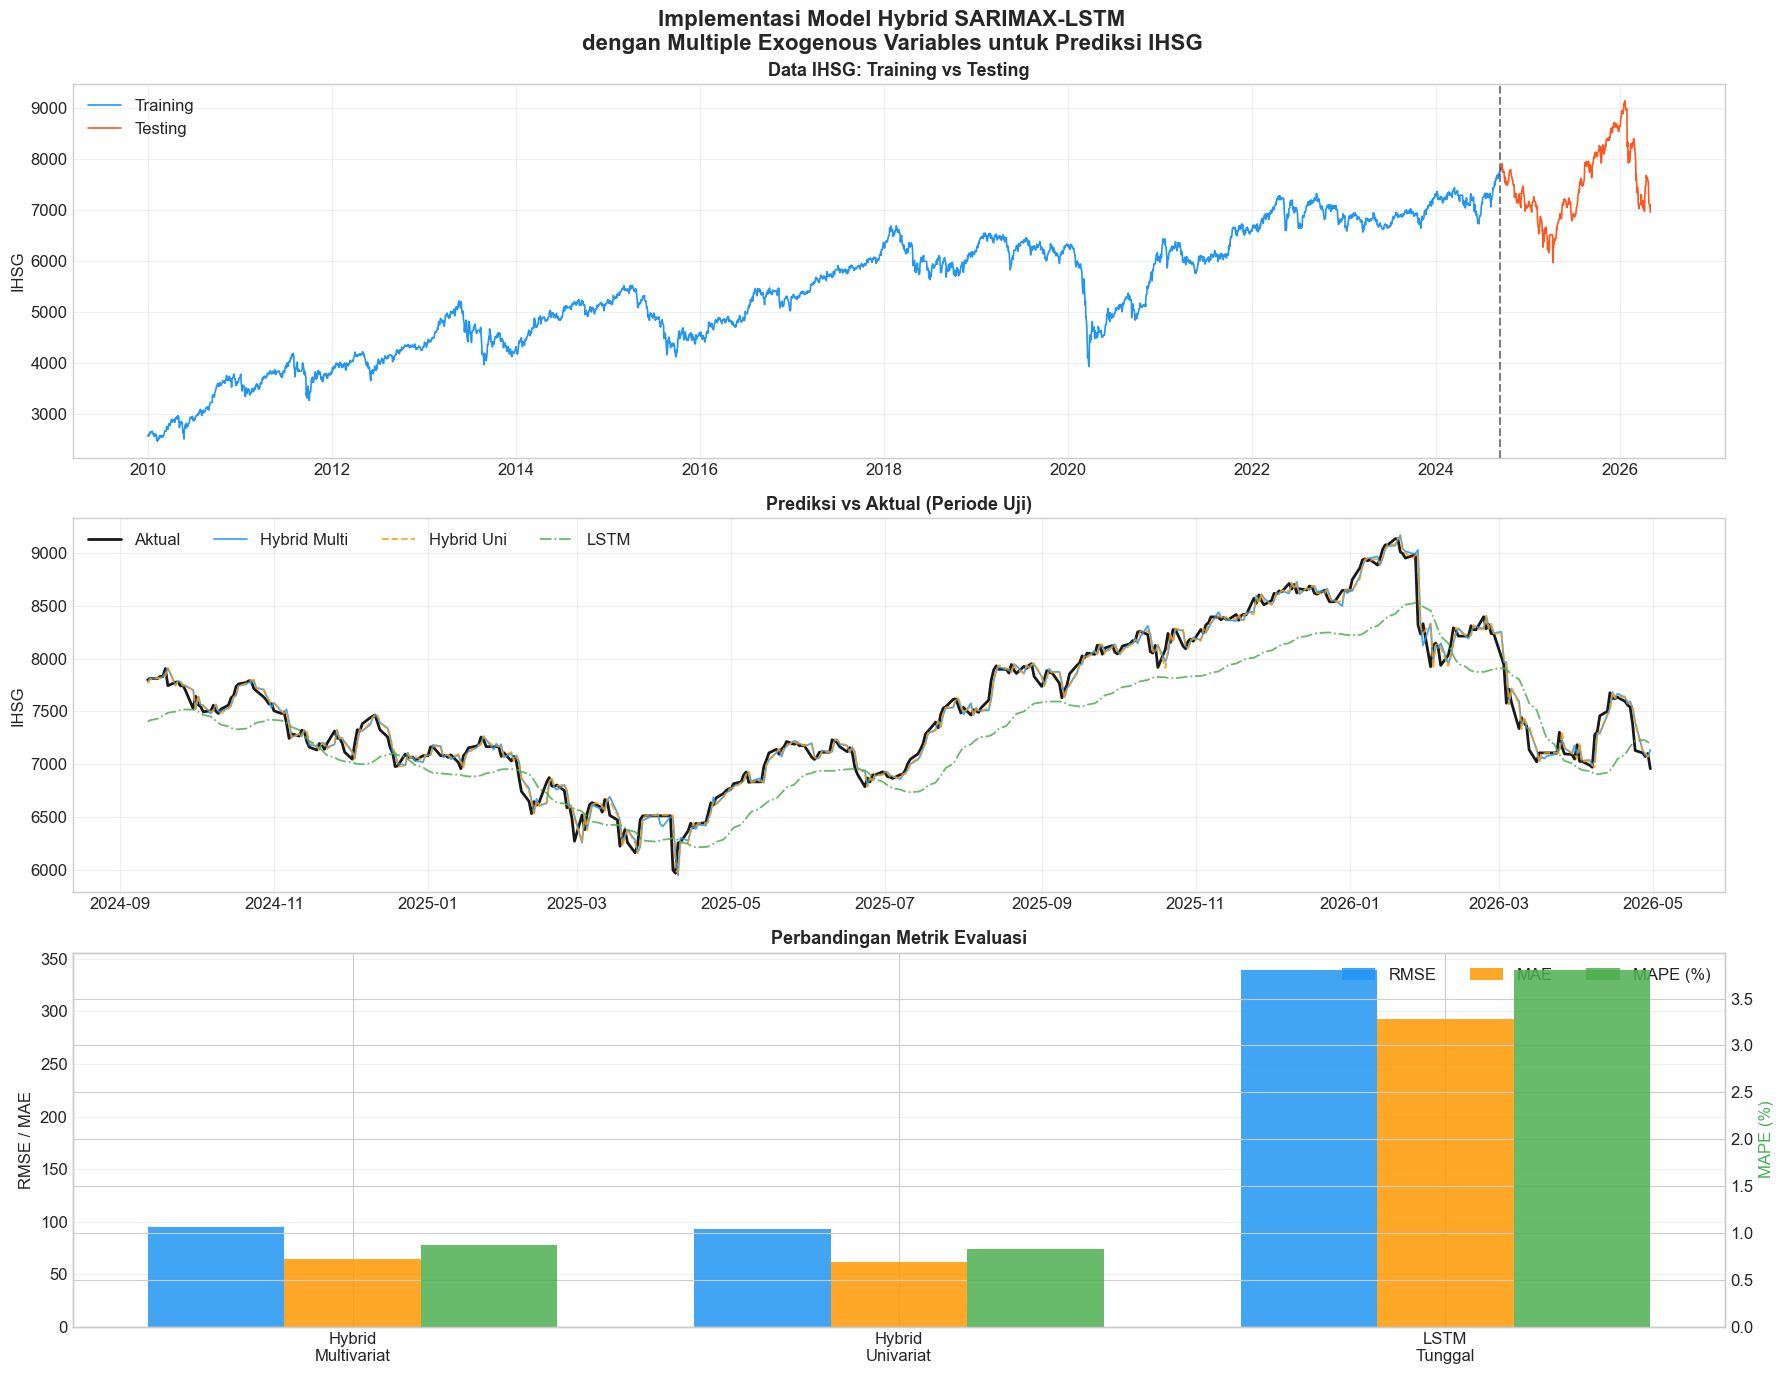

In [138]:
# Final comprehensive plot
fig = plt.figure(figsize=(18, 14))

fig.suptitle('Implementasi Model Hybrid SARIMAX-LSTM\ndengan Multiple Exogenous Variables untuk Prediksi IHSG',
             fontsize=16, fontweight='bold', y=0.98)

# Subplot 1: Full data with train/test split
ax1 = fig.add_subplot(3, 1, 1)
ax1.plot(train_data.index, train_data['IHSG'], color='#2196F3', label='Training', linewidth=1.2)
ax1.plot(test_data.index, test_data['IHSG'], color='#FF5722', label='Testing', linewidth=1.2)
ax1.axvline(x=train_data.index[-1], color='black', linestyle='--', alpha=0.5)
ax1.set_title('Data IHSG: Training vs Testing', fontsize=13, fontweight='bold')
ax1.set_ylabel('IHSG')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2: Predictions comparison
ax2 = fig.add_subplot(3, 1, 2)
ax2.plot(common_idx, actual_common, color='black', linewidth=2, label='Aktual', alpha=0.9)
ax2.plot(common_idx, hybrid_multi_common, color='#2196F3', linewidth=1.3, label='Hybrid Multi', alpha=0.85)
ax2.plot(common_idx, hybrid_uni_common, color='#FF9800', linewidth=1.3, label='Hybrid Uni', linestyle='--', alpha=0.85)
ax2.plot(common_idx, lstm_sa_common, color='#4CAF50', linewidth=1.3, label='LSTM', linestyle='-.', alpha=0.85)
ax2.set_title('Prediksi vs Aktual (Periode Uji)', fontsize=13, fontweight='bold')
ax2.set_ylabel('IHSG')
ax2.legend(ncol=4)
ax2.grid(True, alpha=0.3)

# Subplot 3: Metric comparison
ax3 = fig.add_subplot(3, 1, 3)
models_names = ['Hybrid\nMultivariat', 'Hybrid\nUnivariat', 'LSTM\nTunggal']
x = np.arange(len(models_names))
width = 0.25

rmse_vals = [hybrid_multi_metrics['RMSE'], hybrid_uni_metrics['RMSE'], lstm_standalone_metrics['RMSE']]
mae_vals = [hybrid_multi_metrics['MAE'], hybrid_uni_metrics['MAE'], lstm_standalone_metrics['MAE']]
mape_vals = [hybrid_multi_metrics['MAPE'], hybrid_uni_metrics['MAPE'], lstm_standalone_metrics['MAPE']]

ax3_rmse = ax3.bar(x - width, rmse_vals, width, label='RMSE', color='#2196F3', alpha=0.85)
ax3_mae = ax3.bar(x, mae_vals, width, label='MAE', color='#FF9800', alpha=0.85)

ax3b = ax3.twinx()
ax3_mape = ax3b.bar(x + width, mape_vals, width, label='MAPE (%)', color='#4CAF50', alpha=0.85)
ax3b.set_ylabel('MAPE (%)', color='#4CAF50')

ax3.set_title('Perbandingan Metrik Evaluasi', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(models_names)
ax3.set_ylabel('RMSE / MAE')
ax3.grid(True, alpha=0.3, axis='y')

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper right', ncol=3)

plt.tight_layout()
plt.savefig('final_summary.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 13. Simpan Hasil

Menyimpan hasil prediksi dan metrik evaluasi ke file CSV.

In [139]:
# Save predictions to CSV
predictions_df = pd.DataFrame({
    'Date': common_idx,
    'Actual_IHSG': actual_common.values,
    'Hybrid_Multivariat': hybrid_multi_common,
    'Hybrid_Univariat': hybrid_uni_common,
    'LSTM_Tunggal': lstm_sa_common
})
predictions_df.to_csv('predictions_results.csv', index=False)
print("✅ Predictions saved to 'predictions_results.csv'")

# Save metrics to CSV
metrics_export = pd.DataFrame({
    'Model': ['Hybrid SARIMAX-LSTM Multivariat', 'Hybrid SARIMAX-LSTM Univariat', 'LSTM Tunggal'],
    'RMSE': [hybrid_multi_metrics['RMSE'], hybrid_uni_metrics['RMSE'], lstm_standalone_metrics['RMSE']],
    'MAE': [hybrid_multi_metrics['MAE'], hybrid_uni_metrics['MAE'], lstm_standalone_metrics['MAE']],
    'MAPE (%)': [hybrid_multi_metrics['MAPE'], hybrid_uni_metrics['MAPE'], lstm_standalone_metrics['MAPE']]
})
metrics_export.to_csv('evaluation_metrics.csv', index=False)
print("✅ Metrics saved to 'evaluation_metrics.csv'")

# Save cleaned dataset
df.to_csv('cleaned_dataset.csv')
print("✅ Cleaned dataset saved to 'cleaned_dataset.csv'")

print("\n📁 Output files:")
print("  - predictions_results.csv")
print("  - evaluation_metrics.csv")
print("  - cleaned_dataset.csv")
print("  - *.png (semua visualisasi)")

✅ Predictions saved to 'predictions_results.csv'
✅ Metrics saved to 'evaluation_metrics.csv'
✅ Cleaned dataset saved to 'cleaned_dataset.csv'

📁 Output files:
  - predictions_results.csv
  - evaluation_metrics.csv
  - cleaned_dataset.csv
  - *.png (semua visualisasi)


---

## Catatan Teknis

### Parameter Model
| Parameter | Nilai |
|---|---|
| Periode Data | Januari 2019 – Desember 2024 |
| Train/Test Split | 80% / 20% |
| SARIMAX Order | Ditentukan melalui Grid Search (AIC) |
| SARIMAX Prediction | Rolling one-step-ahead (append, refit=False) |
| LSTM Look-back | 30 time steps |
| LSTM Units | 50 |
| LSTM Dropout | 0.2 |
| Learning Rate | 0.001 |
| Optimizer | Adam |
| Epochs | 100 (Early Stopping patience=10) |
| Batch Size | 32 |
| Scaler | MinMaxScaler [0, 1] |

### Referensi
1. Achmadi dkk. (2023) — Hybrid SARIMAX-LSTM untuk prediksi cryptocurrency
2. Yusuf (2021) — LSTM untuk prediksi IHSG
3. Hochreiter & Schmidhuber (1997) — Long Short-Term Memory

Mulai menghitung prediksi masa depan...
Selesai! Membuat visualisasi...


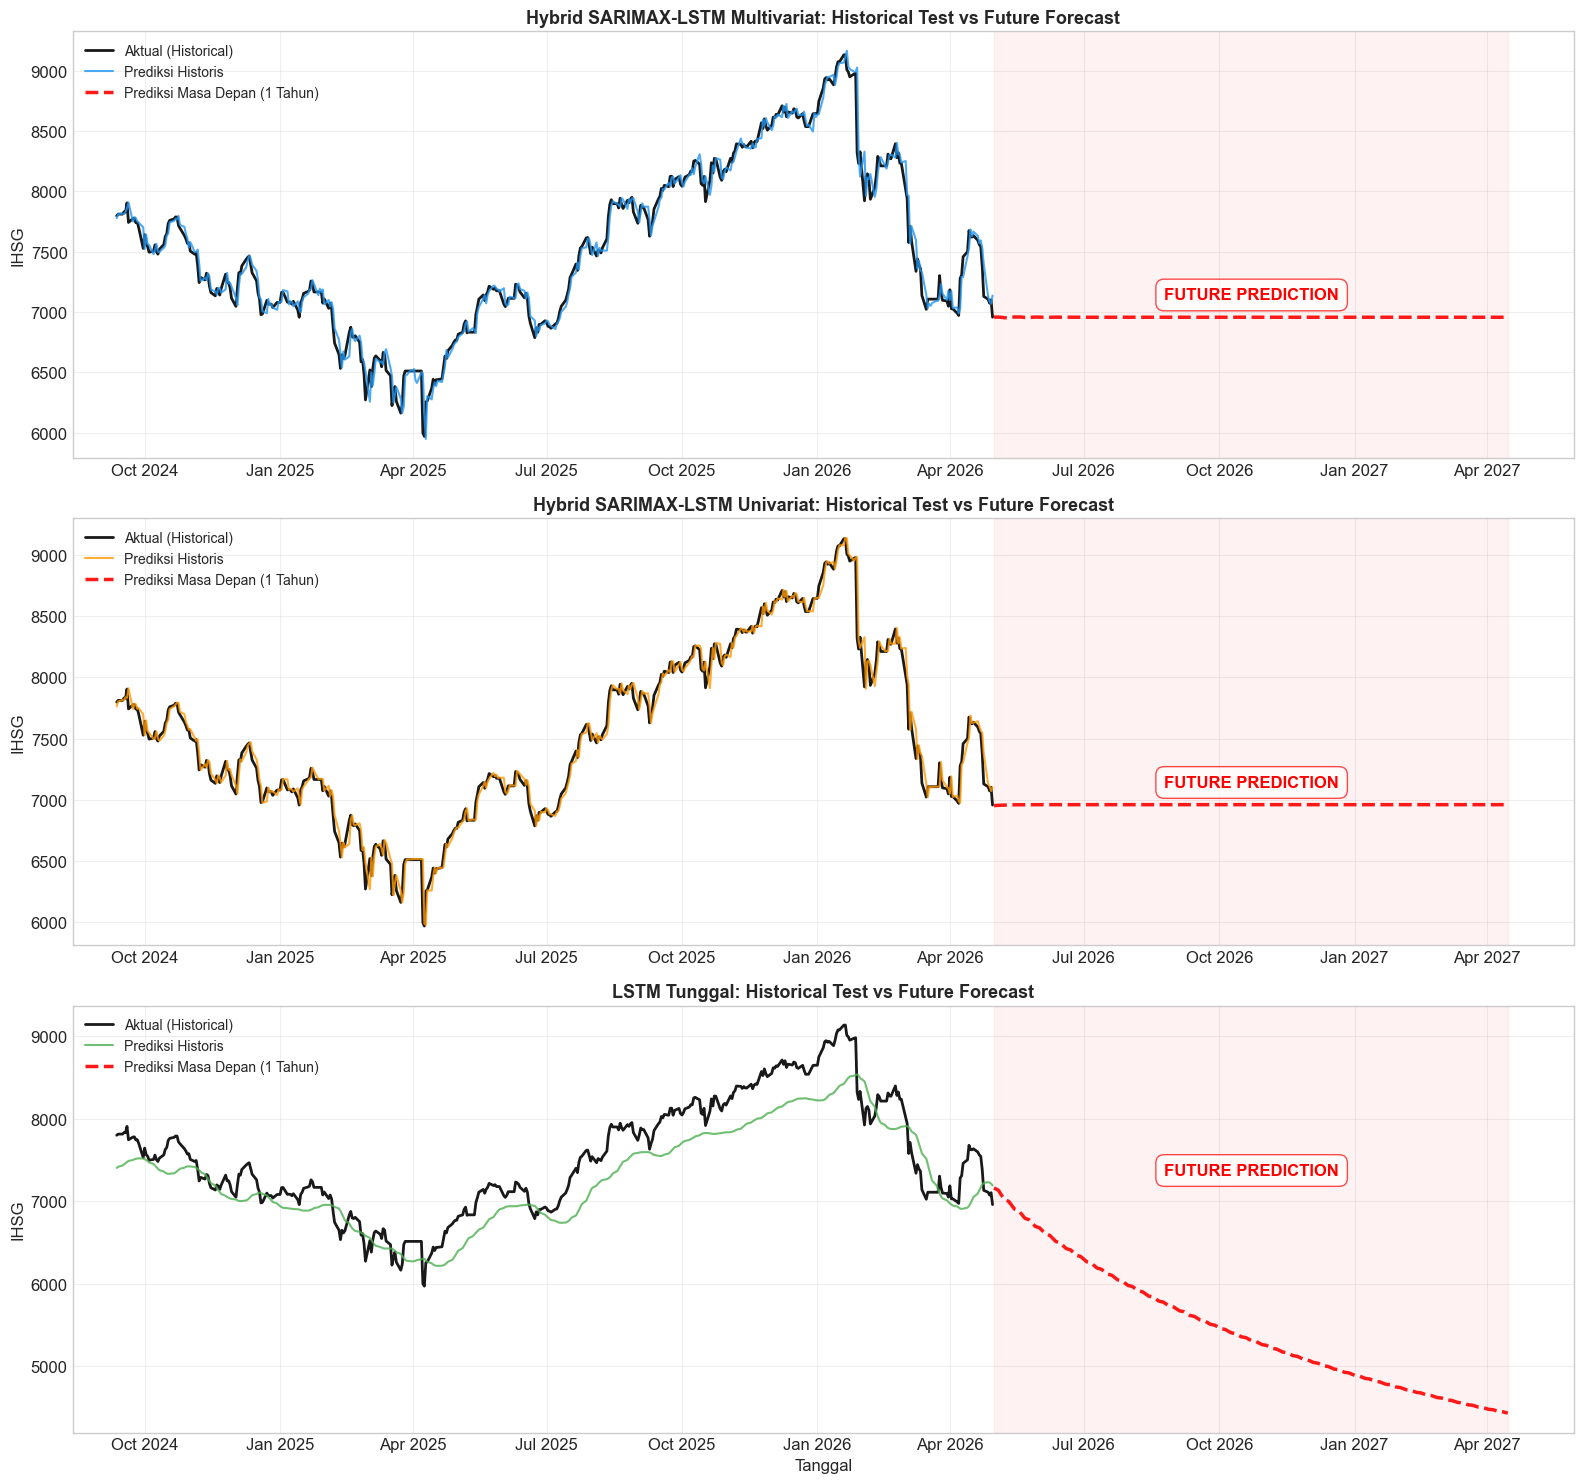

In [ ]:
# ================================================================
# PREDIKSI MASA DEPAN (OUT-OF-SAMPLE FORECAST)
# Memprediksi 250 hari kerja (kurang lebih 1 tahun ke depan)
# ================================================================

future_steps = 180

# 1. Buat index tanggal masa depan (Business Days)
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_steps, freq='B')

print("Mulai menghitung prediksi masa depan...")

# --- 1. SARIMAX Univariat Future ---
# Forecast langsung dari akhir data menggunakan model yang sudah diperbarui
future_sarimax_uni = current_result_uni.forecast(steps=future_steps)

# --- 2. LSTM Residual Univariat Future (Iterative) ---
current_resid_seq = resid_uni_test_scaled[-LOOK_BACK:].reshape(1, LOOK_BACK, 1)
future_resid_uni_scaled = []

for _ in range(future_steps):
    next_resid = lstm_resid_uni.predict(current_resid_seq, verbose=0)
    future_resid_uni_scaled.append(next_resid[0, 0])
    current_resid_seq = np.append(current_resid_seq[:, 1:, :], next_resid.reshape(1, 1, 1), axis=1)

future_resid_uni = scaler_resid_uni.inverse_transform(np.array(future_resid_uni_scaled).reshape(-1, 1)).flatten()
future_hybrid_uni = future_sarimax_uni.values + future_resid_uni


# --- 3. LSTM Tunggal Future (Iterative) ---
current_ihsg_seq = test_ihsg_scaled[-LOOK_BACK:].reshape(1, LOOK_BACK, 1)
future_lstm_sa_scaled = []

for _ in range(future_steps):
    next_ihsg = lstm_standalone.predict(current_ihsg_seq, verbose=0)
    future_lstm_sa_scaled.append(next_ihsg[0, 0])
    current_ihsg_seq = np.append(current_ihsg_seq[:, 1:, :], next_ihsg.reshape(1, 1, 1), axis=1)

future_lstm_sa = scaler_ihsg.inverse_transform(np.array(future_lstm_sa_scaled).reshape(-1, 1)).flatten()


# --- 4. SARIMAX Multivariat Future ---
# ASUMSI NAIVE: Nilai eksogen (Kurs, Emas) masa depan dianggap stabil seperti hari terakhir di dataset
last_exog = df[exog_cols].iloc[-1:]
future_exog = pd.DataFrame(np.repeat(last_exog.values, future_steps, axis=0), 
                           columns=exog_cols, index=future_dates)

future_sarimax_multi = current_result.forecast(steps=future_steps, exog=future_exog)

current_resid_multi_seq = resid_multi_test_scaled[-LOOK_BACK:].reshape(1, LOOK_BACK, 1)
future_resid_multi_scaled = []

for _ in range(future_steps):
    next_resid = lstm_resid_multi.predict(current_resid_multi_seq, verbose=0)
    future_resid_multi_scaled.append(next_resid[0, 0])
    current_resid_multi_seq = np.append(current_resid_multi_seq[:, 1:, :], next_resid.reshape(1, 1, 1), axis=1)

future_resid_multi = scaler_resid_multi.inverse_transform(np.array(future_resid_multi_scaled).reshape(-1, 1)).flatten()
future_hybrid_multi = future_sarimax_multi.values + future_resid_multi

print("Selesai! Membuat visualisasi...")

# ================================================================
# PLOTTING PREDIKSI MASA DEPAN
# ================================================================
fig, axes = plt.subplots(3, 1, figsize=(16, 15))

models_data_future = [
    ('Hybrid SARIMAX-LSTM Multivariat', hybrid_multi_common, future_hybrid_multi, '#2196F3'),
    ('Hybrid SARIMAX-LSTM Univariat', hybrid_uni_common, future_hybrid_uni, '#FF9800'),
    ('LSTM Tunggal', lstm_sa_common, future_lstm_sa, '#4CAF50')
]

for ax, (name, pred_test, pred_future, color) in zip(axes, models_data_future):
    # 1. Plot Data Aktual (fokus ke area test agar grafik tidak terlalu padat)
    ax.plot(test_data.index, test_data['IHSG'], color='black', linewidth=2, label='Aktual (Historical)', alpha=0.9)
    
    # 2. Plot Prediksi Historis (di masa test_data)
    ax.plot(common_idx, pred_test, color=color, linewidth=1.5, label=f'Prediksi Historis', alpha=0.8)
    
    # 3. Plot Prediksi MASA DEPAN (Garis Putus-putus Merah)
    ax.plot(future_dates, pred_future, color='red', linewidth=2.5, linestyle='--', label=f'Prediksi Masa Depan (1 Tahun)', alpha=0.9)
    
    # 4. Highlight kotak merah tipis untuk menandakan zona masa depan
    ax.axvspan(future_dates[0], future_dates[-1], color='red', alpha=0.05)
    
    # 5. Teks Label "FUTURE PREDICTION"
    center_future_date = future_dates[len(future_dates)//2]
    ax.text(center_future_date, np.max(pred_future) + 120, 
            'FUTURE PREDICTION', color='red', fontsize=12, fontweight='bold', 
            ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.7, edgecolor='red', boxstyle='round,pad=0.5'))

    ax.set_title(f'{name}: Historical Test vs Future Forecast', fontsize=13, fontweight='bold')
    ax.set_ylabel('IHSG')
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    
    # Batasi view (zoom-in) dari awal periode test hingga akhir masa depan
    ax.set_xlim(test_data.index[0] - pd.Timedelta(days=30), future_dates[-1] + pd.Timedelta(days=45))

axes[-1].set_xlabel('Tanggal')
plt.tight_layout()
plt.savefig('future_predictions_final.png', dpi=150, bbox_inches='tight')
plt.show()
